# Spatial Proteomics of Murine Acute Kidney Injury

**The question.** Unilateral ureteral obstruction (UUO) in mice produces a stereotyped injury trajectory: neutrophil infiltration within hours, myeloid expansion by days, fibroblast activation and interstitial remodeling by the end of the first week. Does that trajectory show up in spatial protein architecture at tissue-patch resolution clearly enough for a small cohort to surface candidate findings worth powering in a larger study?

**What we did.** Imaging Mass Cytometry (IMC) on 24 regions of interest from 8 mice (n=2 per timepoint at Sham, D1, D3, D7), using a nine-marker panel covering the five biological axes of AKI: immune infiltration (CD45, CD11b, Ly6G), myeloid polarization (CD206), vascular integrity (CD31, CD34), mesenchymal/fibrotic response (CD140a, CD140b), and tissue injury/adhesion (CD44). The IMC output is a stack of per-pixel ion-count images, which we segment into ~10 µm tissue patches — each patch is the unit of analysis in everything below. Each patch is annotated two ways in parallel: discrete cell-type labels (15 categories via boolean gating rules, plus `unassigned`) and continuous lineage memberships (three non-exclusive scores for immune, endothelial, and stromal character). Three pre-registered endpoint families compare these annotations across timepoints.

**Candidate finding.** Between Sham and Day 7, stromal-marker-positive tissue appears less *stromal-only* and more *multi-lineage*. The triple-positive interface category (patches scoring on all three lineages simultaneously) rises; tissue not assigned to any named compartment acquires broad CD44⁺ injury-marker activation; activated subtypes of fibroblast and myeloid populations shift relative to their bare-lineage parents. This converges from non-identical analytical lenses and is an observation worth testing in a powered follow-up, not a tested claim.

**What this notebook is for.** §1–§5 visualize the per-patch annotations — who the cell types are, how they distribute, what neighborhoods they occupy, how published biology connects the panel markers. §6 reads out the headline-flagged Sham→D7 endpoints from `endpoint_summary.csv` (840 endpoint rows × 46 columns post-remediation) across all three families and across both annotation surfaces (lineage interface and discrete cell type). §7 converts the effect sizes into sample-size requirements for a powered follow-up. The companion kidney notebook (`notebooks/biological_narratives/kidney_injury_spatial_analysis.ipynb`) carries the visualizations of those endpoints.

**Honest scope.** At n=2 mice per timepoint, no statistical test can reach conventional significance (Mann-Whitney U produces only three possible p-values: ~0.33, 0.67, 1.0). We report effect sizes (Hedges' g) with Bayesian shrinkage under three explicit priors on how skeptical to be about pilot effects; the range is the finding, not any single number. The continuous lineage system normalizes against a Sham-pooled per-mouse reference (artifact: `results/biological_analysis/sham_reference_10.0um.json`), and the lineage-interface composition CLR endpoint is reported under two non-identical normalization paths (Sham-reference-centered sigmoid and raw-marker Sham-reference percentile) so any normalization-driven inflation or sign-flip is visible per row in `endpoint_summary.csv`.

**Pre-registration:** `analysis_plans/temporal_interfaces_plan.md`.


> **Notebook status (post-remediation 2026-05-21).** Code-cell outputs in this notebook were last executed before the spec-literal-gate restoration. Numerical outputs printed inline (e.g., "Assignment rate: 27.5% – 44.0% (mean 34.3%)") reflect the prior ontology state and are **stale**. Authoritative current values: assignment rate 8.9%–18.8% (mean 13.6%); `endpoint_summary.csv` = 840 × 46 with 263 `is_headline=True`; neutrophil-CD44 Sham→D7 = 31.8% → 81.1% (g_neut=+1.00). Markdown narrative cells have been brought current; the underlying CSVs are current; only the cached cell outputs are stale, and they will refresh on re-execution. See `RESULTS.md` and `endpoint_summary.csv` for current numbers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import networkx as nx
from pathlib import Path
import sys

# --- Project root discovery ---
_candidates = [Path().resolve()] + [Path().resolve().parents[i] for i in range(5)]
project_root = None
for _c in _candidates:
    if (_c / 'config.json').exists():
        project_root = _c
        break
assert project_root is not None, 'Could not find project root (no config.json)'
sys.path.insert(0, str(project_root))

# --- Analysis config (cell type gating rules, family lineage map) ---
with open(project_root / 'config.json') as f:
    config = json.load(f)

# --- Display config (colors, labels, plot defaults) lives in viz.json ---
from src.viz_utils import VizConfig
viz = VizConfig.load(project_root / 'viz.json')
viz.apply_rcparams()

# Shorthand for the plot code below
CT_COLORS = viz.cell_type_colors
CT_LABELS = viz.cell_type_labels
CT_ORDER  = viz.cell_type_order
TP_ORDER  = viz.timepoint_order
TP_COLORS = viz.timepoint_colors

GENE_AXIS_COLOR = {
    'PTPRC': '#E63946', 'ITGAM': '#E63946', 'Ly6g': '#D62828',
    'MRC1': '#FCBF49', 'PDGFRA': '#2A9D8F', 'PDGFRB': '#2A9D8F',
    'PECAM1': '#457B9D', 'CD34': '#06AED5', 'CD44': '#9B59B6',
}
GENE_AXIS_LABEL = {
    'PTPRC': 'Immune', 'ITGAM': 'Immune', 'Ly6g': 'Immune',
    'MRC1': 'Immune', 'PDGFRA': 'Stromal', 'PDGFRB': 'Stromal',
    'PECAM1': 'Vascular', 'CD34': 'Vascular', 'CD44': 'Injury/Adhesion',
}

# --- Load all data ---
bio_dir = project_root / 'results' / 'biological_analysis'
da_dir = bio_dir / 'differential_abundance'
sp_dir = bio_dir / 'spatial_neighborhoods'

temporal_da = pd.read_csv(da_dir / 'temporal_differential_abundance.csv')  # Layer A: 15 config cell types
regional_da = pd.read_csv(da_dir / 'regional_differential_abundance.csv')
try:
    temporal_rollups = pd.read_csv(da_dir / 'temporal_lineage_rollups.csv')  # Layer B: 3 lineage axes + 5 subtype aggregates
except FileNotFoundError:
    temporal_rollups = pd.DataFrame()
roi_abundances = pd.read_csv(da_dir / 'roi_abundances.csv')
temporal_enrich = pd.read_csv(sp_dir / 'temporal_neighborhood_enrichments_mouse.csv')
regional_enrich = pd.read_csv(sp_dir / 'regional_neighborhood_enrichments_mouse.csv')
indra_annot = pd.read_csv(bio_dir / 'indra_finding_annotations.csv')

with open(bio_dir / 'indra_panel_context.json') as f:
    indra_ctx = json.load(f)


# Ensure timepoint ordering
temporal_da['timepoint_1'] = pd.Categorical(temporal_da['timepoint_1'], categories=TP_ORDER, ordered=True)
roi_abundances['timepoint'] = pd.Categorical(roi_abundances['timepoint'], categories=TP_ORDER, ordered=True)
temporal_enrich['timepoint'] = pd.Categorical(temporal_enrich['timepoint'], categories=TP_ORDER, ordered=True)

def ct_label(ct):
    return viz.ct_label(ct)

print(f'Loaded: {len(temporal_da)} temporal DA, {len(regional_da)} regional DA, '
      f'{len(roi_abundances)} ROIs, {len(temporal_enrich)} enrichments, '
      f'{len(indra_annot)} INDRA annotations')


Loaded: 90 temporal DA, 45 regional DA, 24 ROIs, 900 enrichments, 413 INDRA annotations


---
## 1. Study Design

| Parameter | Value |
|-----------|-------|
| Species | Mouse (C57BL/6) |
| Model | Unilateral ureteral obstruction (UUO) — ligation of one ureter induces progressive fibrosis in the obstructed kidney |
| Timepoints | Sham (surgery, no ligation) · Day 1 (acute inflammation) · Day 3 (myeloid expansion peak) · Day 7 (early fibrotic remodeling) |
| Biological replicates | n=2 mice per timepoint (8 mice total) |
| ROIs | 24 (~3 per mouse; cortex and medulla sampled) |
| Markers | 9 protein channels via IMC |
| Segmentation | SLIC superpixels at 10 µm (pinned a priori; plan §2) |
| Cell typing | Dual: discrete boolean gating (15 types) + continuous multi-label memberships (3 lineage axes) |
| Design | Cross-sectional (different mice per timepoint, not longitudinal) |

### What the panel is set up to see

| Marker | Gene | Biological signal in UUO |
|---|---|---|
| CD45 | PTPRC | pan-leukocyte; rises with immune infiltration |
| CD11b | ITGAM | myeloid cells — neutrophils, monocytes, macrophages |
| Ly6G | Ly6g | murine neutrophils specifically |
| CD206 | MRC1 | alternatively-activated (M2) macrophages; resolution-phase marker |
| CD31 | PECAM1 | endothelium; vascular rarefaction tracks injury |
| CD34 | CD34 | endothelial progenitors / hematopoietic stem cells |
| CD140a | PDGFRA | fibroblast lineage anchor in this pipeline |
| CD140b | PDGFRB | pericytes / activated mesenchymal marker; used as activation overlay |
| CD44 | CD44 | tissue injury / hyaluronan receptor; the only panel gene with direct MESH annotation to AKI |

Panel markers were selected against the INDRA/CoGEx knowledge graph (§5), which captures 117 literature-documented causal relationships among the 8 groundable genes (Ly6g is murine-specific with limited INDRA coverage). Five of the eight are regulated by TGF-β, the master regulator of renal fibrosis.

### What the panel cannot see

9 markers do not cover tubular epithelium (no E-cadherin, no KIM-1, no aquaporin), lymphocyte subsets (no CD3/CD4/CD8/CD20), dendritic cells, or advanced macrophage polarization states. Approximately 86% of tissue superpixels remain unassigned to any discrete cell type under strict 9-marker gating — this is a consequence of panel design, not a failure of analysis. The continuous lineage system (next section) recovers part of this tissue by allowing multi-lineage assignment.

In [2]:
# --- 1a. Panel grounding table ---
mg = indra_ctx['marker_grounding']
markers = config['channels']['protein_channels']

axis_map = {
    'CD45': 'Pan-leukocyte', 'CD11b': 'Myeloid', 'Ly6G': 'Neutrophil',
    'CD206': 'M2 macrophage', 'CD140a': 'Fibroblast/mesenchymal',
    'CD140b': 'Pericyte/mural', 'CD31': 'Endothelial',
    'CD34': 'Endothelial progenitor', 'CD44': 'Injury/adhesion',
}

panel_rows = []
for m in markers:
    info = mg.get(m, {})
    gene = info.get('gene_name', '-')
    curie = info.get('curie', '-')
    grounded = info.get('grounded', False)
    # Count INDRA statements involving this gene
    n_stmts = sum(1 for s in indra_ctx['indra_statements']
                  if s['source'] == gene or s['target'] == gene)
    panel_rows.append({
        'Marker': m, 'Gene': gene, 'CURIE': curie,
        'Biological Axis': axis_map.get(m, '-'),
        'Grounded': grounded, 'INDRA Relationships': n_stmts,
    })

panel_df = pd.DataFrame(panel_rows)
print(panel_df.to_string(index=False))
print(f'\nTotal intra-panel INDRA statements: {len(indra_ctx["indra_statements"])}')
print(f'Grounded markers: {panel_df["Grounded"].sum()}/9 '
      f'(Ly6G is murine-specific, grounded to UniProt but limited INDRA coverage)')

Marker   Gene          CURIE        Biological Axis  Grounded  INDRA Relationships
  CD45  PTPRC      hgnc:9666          Pan-leukocyte      True                   39
 CD11b  ITGAM      hgnc:6149                Myeloid      True                   35
  Ly6G   Ly6g uniprot:P35461             Neutrophil      True                    9
CD140a PDGFRA      hgnc:8803 Fibroblast/mesenchymal      True                   19
CD140b PDGFRB      hgnc:8804         Pericyte/mural      True                   22
  CD31 PECAM1      hgnc:8823            Endothelial      True                   27
  CD34   CD34      hgnc:1662 Endothelial progenitor      True                   36
 CD206   MRC1      hgnc:7228          M2 macrophage      True                   20
  CD44   CD44      hgnc:1681        Injury/adhesion      True                   27

Total intra-panel INDRA statements: 117
Grounded markers: 9/9 (Ly6G is murine-specific, grounded to UniProt but limited INDRA coverage)


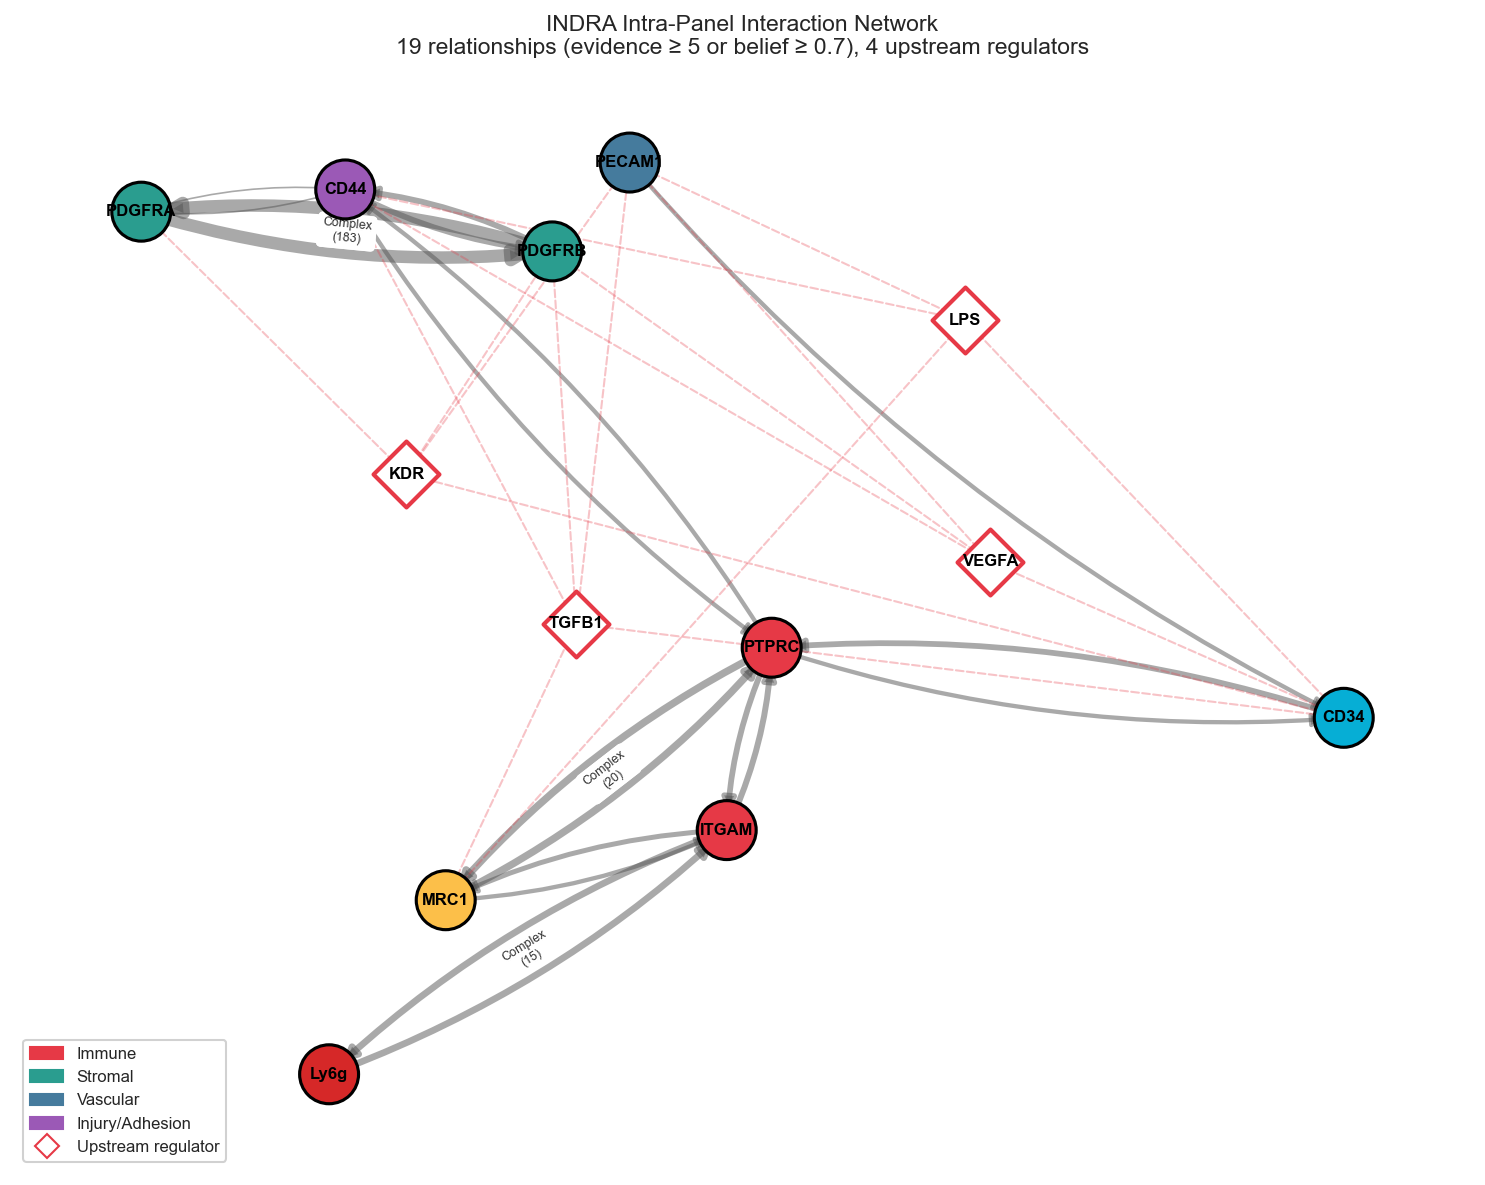

In [3]:
# --- 1b. Panel interaction network ---
stmts = indra_ctx['indra_statements']
regs = indra_ctx['shared_upstream_regulators']

G = nx.DiGraph()

# Add panel gene nodes
panel_genes = set()
for m in markers:
    gene = mg.get(m, {}).get('gene_name', m)
    if gene and gene != '-':
        panel_genes.add(gene)
        G.add_node(gene, node_type='panel')

# Add intra-panel edges (filter: evidence >= 5 or belief >= 0.7)
edge_types = {}
for s in stmts:
    if s['evidence'] >= 5 or s['belief'] >= 0.7:
        key = (s['source'], s['target'])
        if key not in edge_types or s['evidence'] > edge_types[key]['evidence']:
            edge_types[key] = s

for (src, tgt), s in edge_types.items():
    G.add_edge(src, tgt, weight=np.log2(s['evidence'] + 1),
               evidence=s['evidence'], stmt_type=s['type'],
               belief=s['belief'])

# Add top upstream regulators as external nodes
for reg_name, reg_info in regs.items():
    if reg_name not in panel_genes and reg_info['count'] >= 4:
        G.add_node(reg_name, node_type='regulator')
        for tgt in reg_info['targets']:
            if tgt in panel_genes:
                G.add_edge(reg_name, tgt, weight=1.5, evidence=0,
                           stmt_type='Regulation', belief=0.0)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

pos = nx.spring_layout(G, k=2.5, seed=42, iterations=80)

# Draw edges
panel_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('evidence', 0) > 0]
reg_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('evidence', 0) == 0]
panel_widths = [G[u][v]['weight'] * 0.8 for u, v in panel_edges]

nx.draw_networkx_edges(G, pos, edgelist=panel_edges, width=panel_widths,
                       alpha=0.5, edge_color='#555', arrows=True,
                       arrowsize=12, ax=ax, connectionstyle='arc3,rad=0.1')
nx.draw_networkx_edges(G, pos, edgelist=reg_edges, width=1.0,
                       alpha=0.3, edge_color='#E63946', style='dashed',
                       arrows=True, arrowsize=10, ax=ax)

# Draw nodes
panel_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'panel']
reg_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'regulator']

panel_node_colors = [GENE_AXIS_COLOR.get(n, '#999') for n in panel_nodes]
nx.draw_networkx_nodes(G, pos, nodelist=panel_nodes, node_color=panel_node_colors,
                       node_size=800, edgecolors='black', linewidths=1.5, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=reg_nodes, node_color='white',
                       node_size=500, edgecolors='#E63946', linewidths=2,
                       node_shape='D', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

# Edge labels for top interactions
top_edges = sorted(panel_edges, key=lambda e: G[e[0]][e[1]]['evidence'], reverse=True)[:5]
edge_labels = {(u, v): f"{G[u][v]['stmt_type']}\n({G[u][v]['evidence']})"
               for u, v in top_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6,
                             font_color='#333', ax=ax)

# Legend
legend_elements = [
    mpatches.Patch(color='#E63946', label='Immune'),
    mpatches.Patch(color='#2A9D8F', label='Stromal'),
    mpatches.Patch(color='#457B9D', label='Vascular'),
    mpatches.Patch(color='#9B59B6', label='Injury/Adhesion'),
    plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='white',
               markeredgecolor='#E63946', markersize=8, label='Upstream regulator'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8, framealpha=0.9)
ax.set_title('INDRA Intra-Panel Interaction Network\n'
             f'{len(panel_edges)} relationships (evidence \u2265 5 or belief \u2265 0.7), '
             f'{len(reg_nodes)} upstream regulators',
             fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Annotation Layers — What Each Tissue Patch Is Labeled With

Three labeling systems operate on the same ~58,000 tissue patches. They answer different questions. The table below makes the boundaries explicit so the rest of the notebook can be read without ambiguity:

| Layer | What it is | Cardinality | Where used |
|---|---|---|---|
| **A — Cell types** | Config-defined boolean gates (`positive_markers` AND `negative_markers`). Each patch gets ≤1 label. | 15 discrete types + `unassigned` | §3 differential abundance, §4 spatial neighborhoods, §5 INDRA annotation, §6 discrete-cell-type CLR |
| **B — Summary rollups** | Two different aggregations: (a) mean of the 3 continuous lineage scores (immune, endothelial, stromal) per ROI; (b) within-immune subtype *proportions* (neutrophil, m2_macrophage, myeloid, non_myeloid_immune, none). These are summary tables, not peer inferential endpoints to Layer A. | 3 continuous-score means + 5 proportion aggregates | §3D rollup view only |
| **C — Continuous lineage scores** | Per-patch [0,1] scores on 3 lineage axes, from continuous marker aggregation with sigmoid normalization. Each patch has a three-number vector — NOT a discrete label. | 3 axes → 8 interface categories when thresholded | §6 temporal interface analysis |

**Config as source of truth.** The 15 Layer A cell types are defined in `config.json` (`cell_type_annotation.cell_types`). Layer B is derived at analysis time from Layer A proportions and the continuous membership axes. Layer C reads `membership_axes` from the same config but produces a separate annotation parquet consumed by the temporal interface analysis (§6).

The cell below prints the 15 Layer A definitions directly from `config.json` so the roster is visible next to the plots.


In [4]:
# --- Layer A roster: 15 cell types defined in config.json ---
with open(project_root / 'config.json') as f:
    _cfg = json.load(f)
_ct_defs = _cfg['cell_type_annotation']['cell_types']

rows = []
for ct, defn in _ct_defs.items():
    rows.append({
        'cell_type':        ct,
        'label':            viz.ct_label(ct),
        'positive_markers': ' + '.join(defn['positive_markers']),
        'negative_markers': ' + '.join(defn['negative_markers']),
        'family':           defn.get('family', ''),
    })
layer_a_roster = pd.DataFrame(rows)
print(f'Layer A — {len(layer_a_roster)} config-defined cell types:')
print('=' * 110)
with pd.option_context('display.max_colwidth', 45):
    print(layer_a_roster.to_string(index=False))

Layer A — 15 config-defined cell types:
                   cell_type                           label              positive_markers                                            negative_markers            family
                  neutrophil                      Neutrophil                   CD45 + Ly6G                                                 CD31 + CD34 immune_neutrophil
           activated_m2_cd44            Activated M2 (CD44+)   CD45 + CD11b + CD206 + CD44                        CD34 + CD31 + CD140a + Ly6G + CD140b         immune_m2
         activated_m2_cd140b          Activated M2 (CD140b+) CD45 + CD11b + CD206 + CD140b                          CD34 + CD31 + CD140a + Ly6G + CD44         immune_m2
               m2_macrophage                   M2 Macrophage          CD45 + CD11b + CD206                 CD34 + CD31 + CD44 + CD140b + CD140a + Ly6G         immune_m2
      activated_myeloid_cd44       Activated Myeloid (CD44+)           CD45 + CD11b + CD44                CD34 + CD

---
## 2. Tissue Landscape: Two Complementary Annotation Systems

Before effect sizes: what's actually there? The same ~58,000 superpixels are annotated two ways in parallel because no single style captures kidney injury biology completely.

**Discrete boolean gates (15 cell types + `unassigned`).** Priority-ordered rules (e.g., "CD45⁺ AND Ly6G⁺ → neutrophil"). Produces crisp categorical labels for the roughly one-quarter of tissue that matches a defined type. Good for naming specific populations; blind to in-between tissue states.

**Continuous multi-label memberships (3 lineage axes + activation overlays).** Each superpixel gets scores [0,1] on immune, endothelial, and stromal axes simultaneously — non-exclusive, normalized against a Sham-pooled per-mouse reference. Subtype (4 classes) and activation markers (CD44, CD140b) ride on top as independent overlays. Captures tissue interfaces — superpixels on the boundary between vasculature and stroma score on both without being forced into one bucket.

The code cell below decomposes the tissue three ways from `interface_fractions.parquet` — the output that classifies each superpixel as single-lineage, multi-lineage interface, or no-lineage (tubular epithelium, below threshold).


In [5]:
# --- 2a. Tissue decomposition (mouse-mean across 8 mice, lineage threshold = 0.3) ---
ifrac_path = project_root / 'results/biological_analysis/temporal_interfaces/interface_fractions.parquet'
ifrac = pd.read_parquet(ifrac_path)

single_cats = ['immune', 'endothelial', 'stromal']
multi_cats = ['endothelial+immune', 'immune+stromal', 'endothelial+stromal', 'endothelial+immune+stromal']
fracs = ifrac[single_cats + multi_cats + ['none']].mean()
single = fracs[single_cats].sum()
multi = fracs[multi_cats].sum()
none = fracs['none']
assert abs(single + multi + none - 1.0) < 0.001, 'tissue decomposition must sum to 1'

print(f'Tissue decomposition (cohort-mean, threshold=0.3, n_total={int(ifrac["n_total"].sum()):,} superpixels):')
print('=' * 70)
print(f'  Single-lineage (pure immune/endothelial/stromal):           {single:6.1%}')
print(f'  Multi-lineage interfaces (2+ lineages scoring above 0.3):   {multi:6.1%}')
print(f'  No-lineage (all three axes below 0.3; not visible to 9-marker panel): {none:6.1%}')
print()
print('By category:')
for cat in single_cats + multi_cats + ['none']:
    print(f'  {cat:35s} {fracs[cat]:6.1%}')
print()
print('Interpretation: nearly half the tissue is *interfacial* — two or more lineages')
print('scoring together. Discrete gates collapse these into one label or leave them')
print('unassigned. The continuous system retains the multi-lineage information that')
print('the temporal interface analysis (§6) operates on.')


Tissue decomposition (cohort-mean, threshold=0.3, n_total=58,137 superpixels):
  Single-lineage (pure immune/endothelial/stromal):            24.2%
  Multi-lineage interfaces (2+ lineages scoring above 0.3):    56.6%
  No-lineage (all three axes below 0.3; not visible to 9-marker panel):  19.2%

By category:
  immune                                5.9%
  endothelial                          13.5%
  stromal                               4.8%
  endothelial+immune                    9.1%
  immune+stromal                        8.5%
  endothelial+stromal                  10.0%
  endothelial+immune+stromal           29.0%
  none                                 19.2%

Interpretation: nearly half the tissue is *interfacial* — two or more lineages
scoring together. Discrete gates collapse these into one label or leave them
unassigned. The continuous system retains the multi-lineage information that
the temporal interface analysis (§6) operates on.


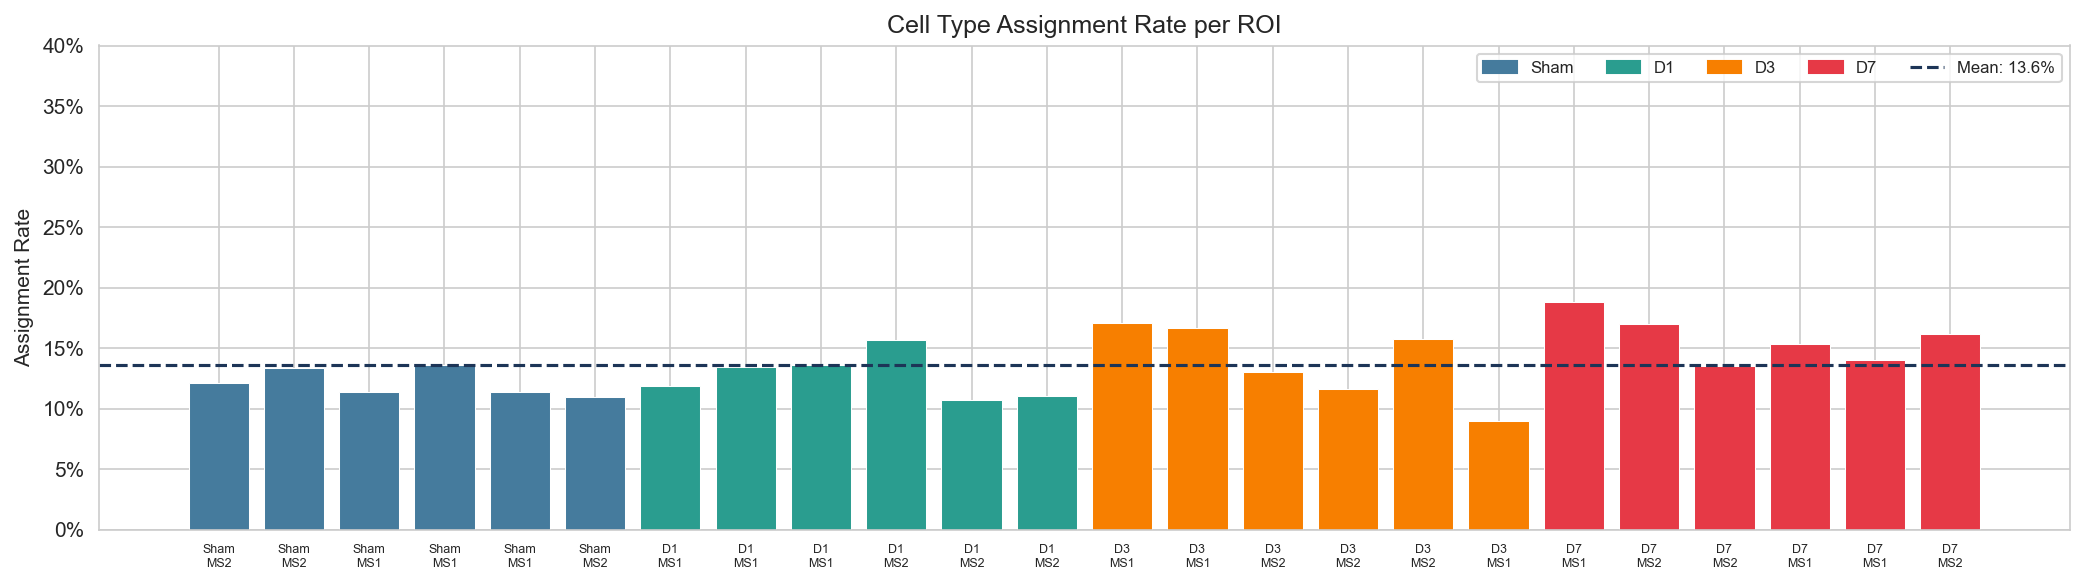

Assignment rate: 8.9% – 18.8% (mean 13.6%)


In [6]:
# --- 2a. Assignment rates by ROI ---
roi_sorted = roi_abundances.sort_values('timepoint')

fig, ax = plt.subplots(figsize=(14, 4))
colors = [TP_COLORS.get(tp, '#999') for tp in roi_sorted['timepoint']]
bars = ax.bar(range(len(roi_sorted)), roi_sorted['assignment_rate'], color=colors,
              edgecolor='white', linewidth=0.5)
ax.axhline(roi_sorted['assignment_rate'].mean(), color='#1D3557', linestyle='--',
           linewidth=1.5, label=f'Mean: {roi_sorted["assignment_rate"].mean():.1%}')
ax.set_xticks(range(len(roi_sorted)))
ax.set_xticklabels([f"{r['timepoint']}\n{r['mouse']}" for _, r in roi_sorted.iterrows()],
                    fontsize=6, rotation=0)
ax.set_ylabel('Assignment Rate')
ax.set_title('Cell Type Assignment Rate per ROI')
ax.set_ylim(0, 0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

handles = [mpatches.Patch(color=c, label=tp) for tp, c in TP_COLORS.items()]
handles.append(plt.Line2D([0], [0], color='#1D3557', linestyle='--',
               label=f'Mean: {roi_sorted["assignment_rate"].mean():.1%}'))
ax.legend(handles=handles, loc='upper right', fontsize=8, ncol=5)
plt.tight_layout()
plt.show()

print(f'Assignment rate: {roi_sorted["assignment_rate"].min():.1%} \u2013 '
      f'{roi_sorted["assignment_rate"].max():.1%} '
      f'(mean {roi_sorted["assignment_rate"].mean():.1%})')

/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_31820/1692925960.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mouse_agg = roi_abundances.groupby(['timepoint', 'mouse'])[existing_prop_cols].mean().reset_index()


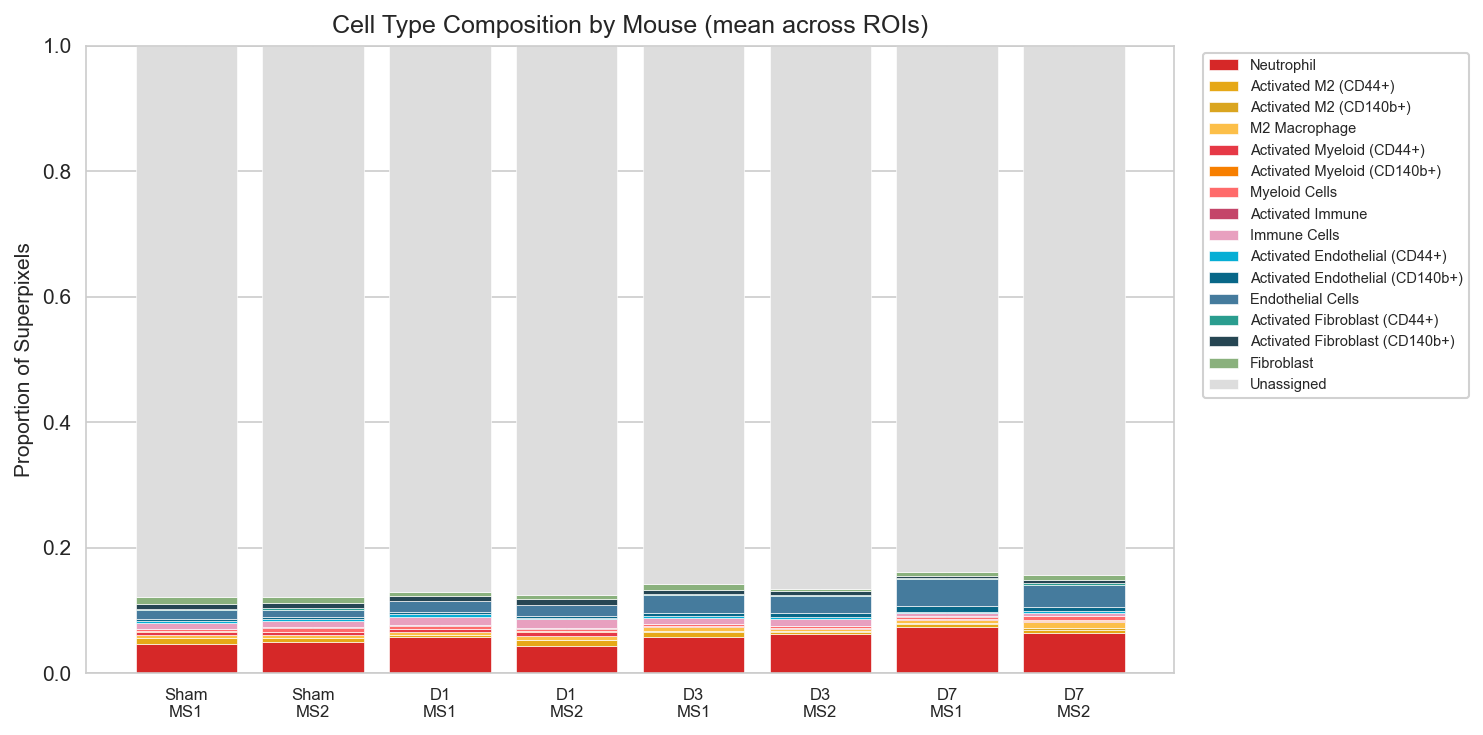

In [7]:
# --- 2b. Cell type composition at mouse level ---
prop_cols = [f'{ct}_prop' for ct in CT_ORDER]
existing_prop_cols = [c for c in prop_cols if c in roi_abundances.columns]
existing_cts = [c.replace('_prop', '') for c in existing_prop_cols]

mouse_agg = roi_abundances.groupby(['timepoint', 'mouse'])[existing_prop_cols].mean().reset_index()
mouse_agg['timepoint'] = pd.Categorical(mouse_agg['timepoint'], categories=TP_ORDER, ordered=True)
mouse_agg = mouse_agg.sort_values(['timepoint', 'mouse'])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(mouse_agg))
bottom = np.zeros(len(mouse_agg))

for ct, col in zip(existing_cts, existing_prop_cols):
    vals = mouse_agg[col].values
    ax.bar(x, vals, bottom=bottom, color=CT_COLORS.get(ct, '#999'),
           label=ct_label(ct), edgecolor='white', linewidth=0.3)
    bottom += vals

# Unassigned on top
unassigned = 1.0 - bottom
ax.bar(x, np.maximum(unassigned, 0), bottom=bottom, color='#DDDDDD',
       label='Unassigned', edgecolor='white', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels([f"{r['timepoint']}\n{r['mouse']}" for _, r in mouse_agg.iterrows()],
                    fontsize=8)
ax.set_ylabel('Proportion of Superpixels')
ax.set_title('Cell Type Composition by Mouse (mean across ROIs)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, framealpha=0.9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_31820/1519973823.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mouse_agg_tp = roi_abundances.groupby(['timepoint', 'mouse'])[existing_prop_cols].mean().reset_index()


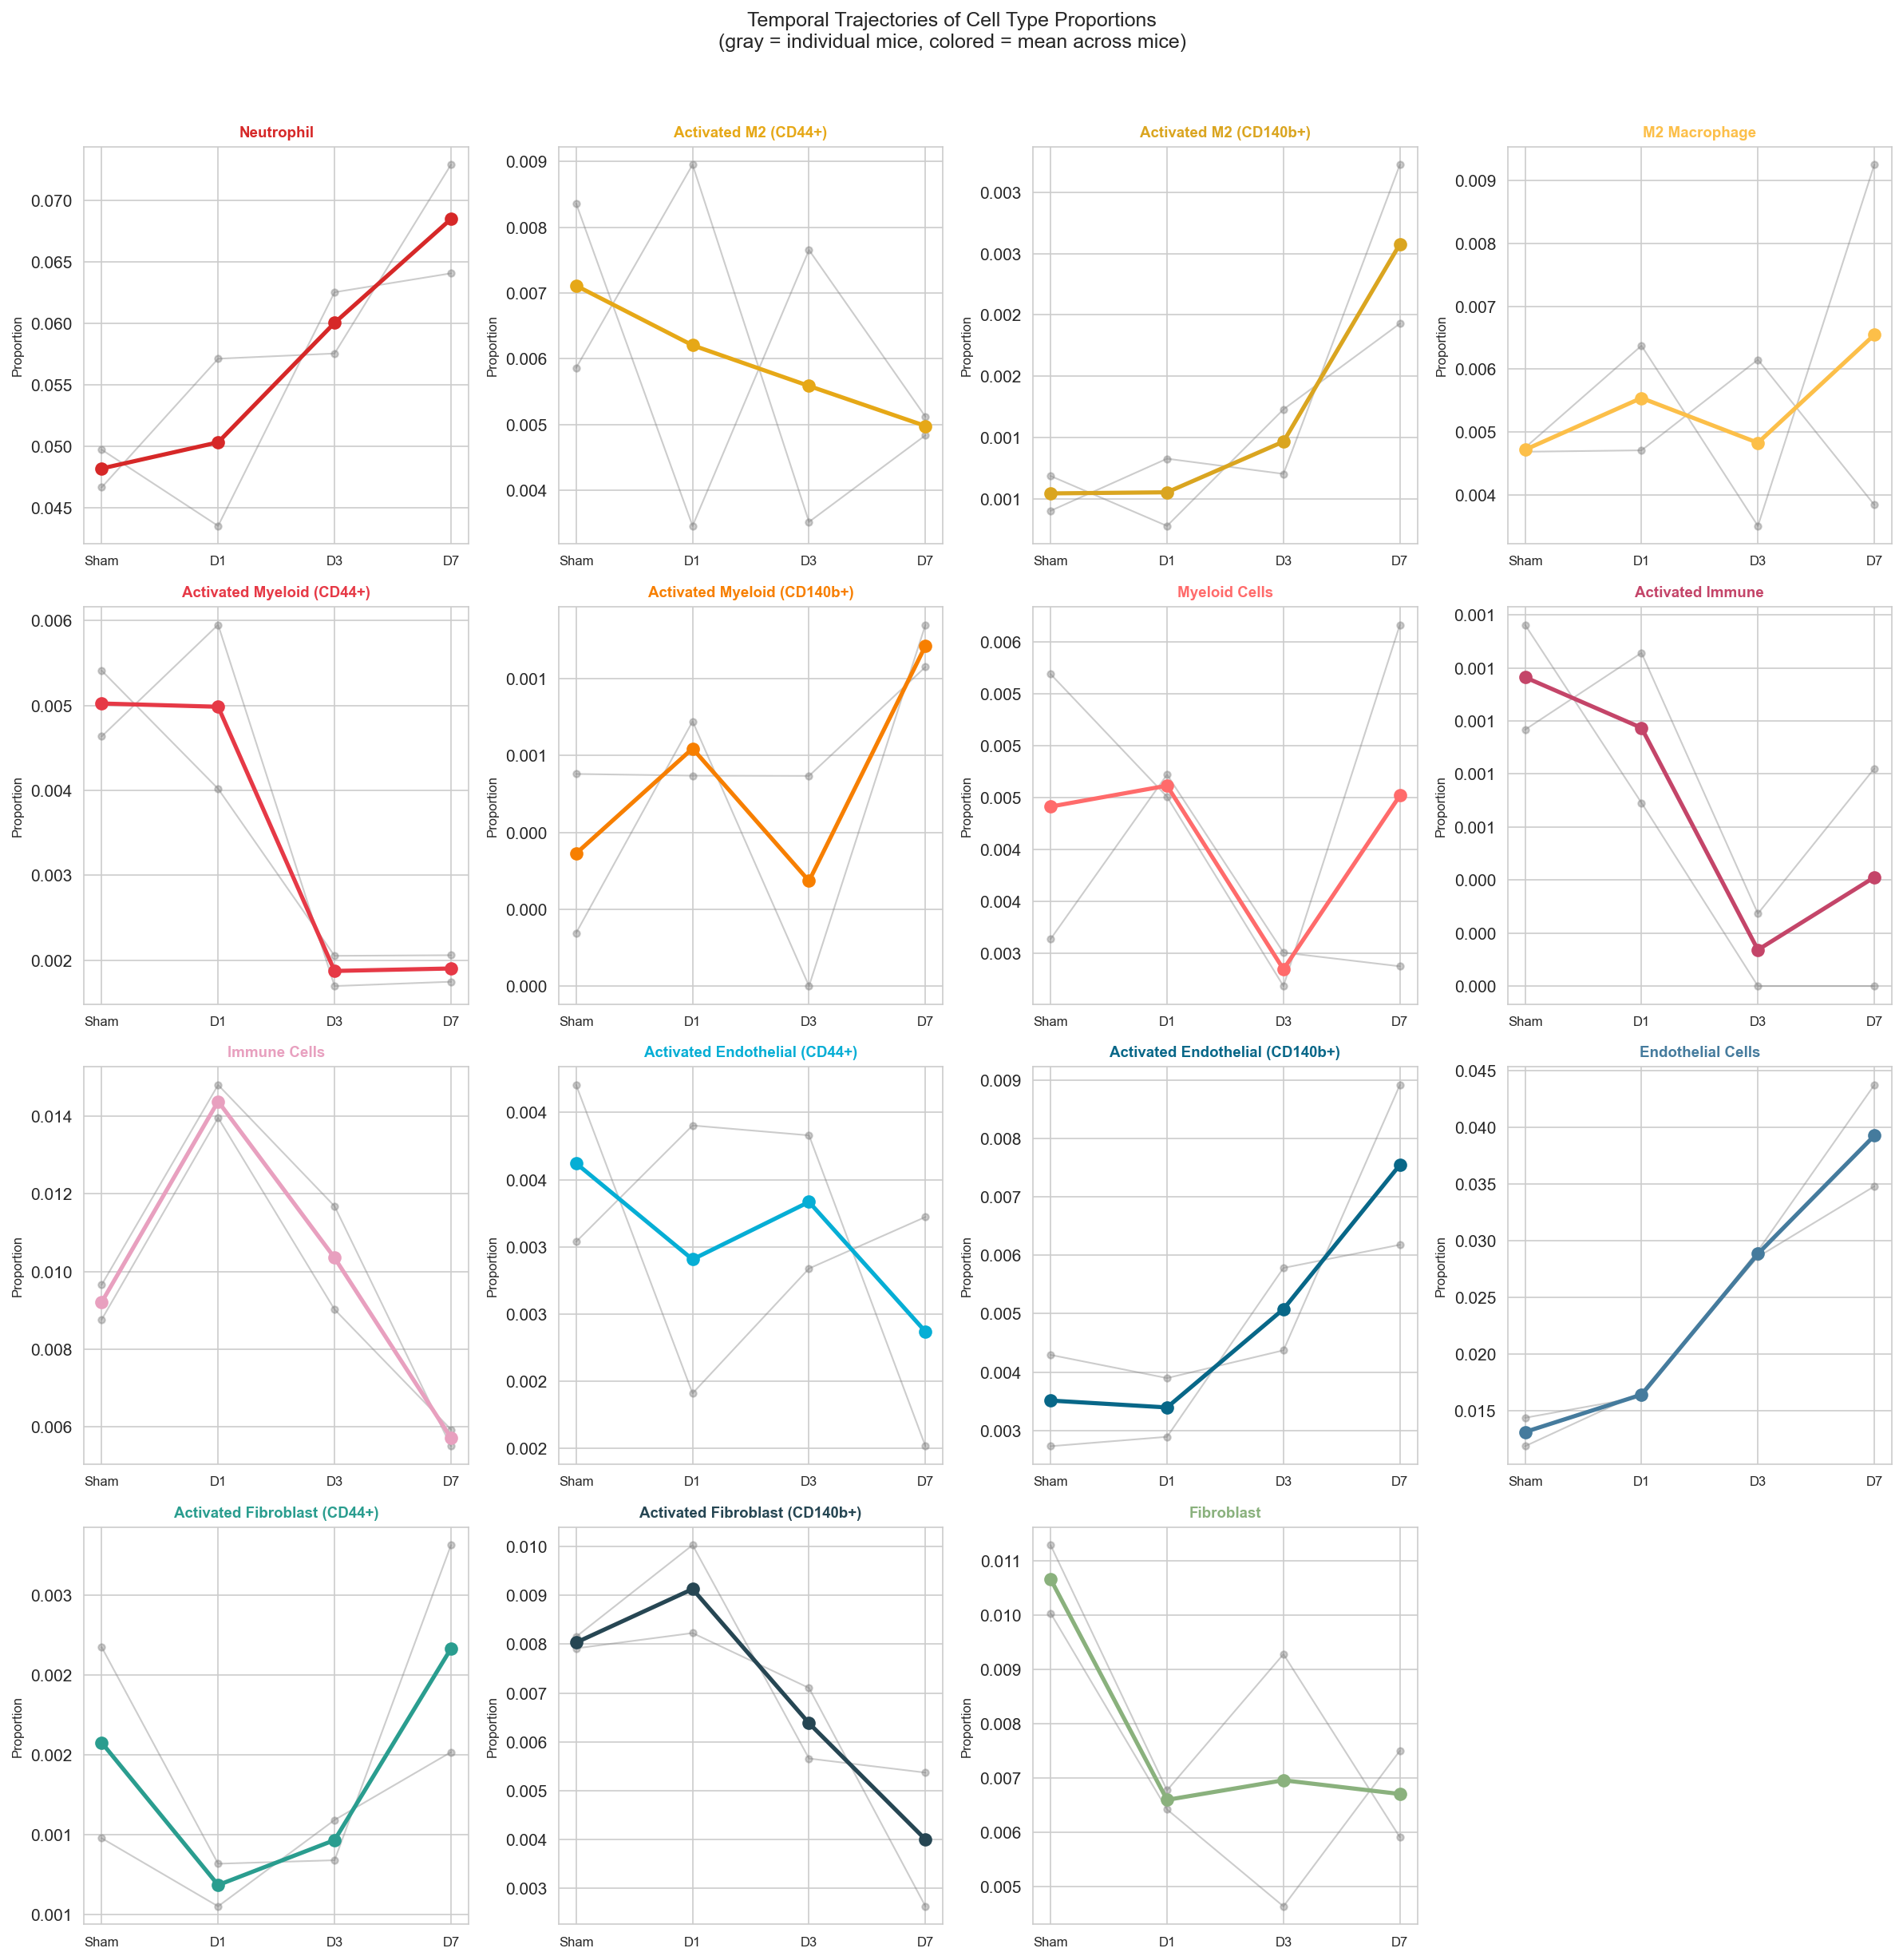

In [8]:
# --- 2c. Temporal trajectories per cell type ---
mouse_agg_tp = roi_abundances.groupby(['timepoint', 'mouse'])[existing_prop_cols].mean().reset_index()
mouse_agg_tp['timepoint'] = pd.Categorical(mouse_agg_tp['timepoint'], categories=TP_ORDER, ordered=True)

n_cts = len(existing_cts)
ncols = 4
nrows = (n_cts + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharey=False)
axes = axes.flatten()

for i, (ct, col) in enumerate(zip(existing_cts, existing_prop_cols)):
    ax = axes[i]
    tp_means = mouse_agg_tp.groupby('timepoint', observed=True)[col].mean()

    # Individual mice as thin lines
    for mouse, grp in mouse_agg_tp.groupby('mouse'):
        grp_sorted = grp.sort_values('timepoint')
        tp_idx = [TP_ORDER.index(tp) for tp in grp_sorted['timepoint']]
        ax.plot(tp_idx, grp_sorted[col].values, 'o-', color='gray',
                alpha=0.4, linewidth=1, markersize=4)

    # Mean line
    mean_vals = [tp_means.get(tp, np.nan) for tp in TP_ORDER]
    ax.plot(range(len(TP_ORDER)), mean_vals, 'o-',
            color=CT_COLORS.get(ct, '#1D3557'), linewidth=2.5, markersize=7, zorder=5)

    ax.set_xticks(range(len(TP_ORDER)))
    ax.set_xticklabels(TP_ORDER, fontsize=8)
    ax.set_title(ct_label(ct), fontsize=9, fontweight='bold',
                 color=CT_COLORS.get(ct, '#333'))
    ax.set_ylabel('Proportion', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.3f}'))

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Temporal Trajectories of Cell Type Proportions\n'
             '(gray = individual mice, colored = mean across mice)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Continuous Lineage Composition

Discrete gates label ~34% of the tissue. What about the other ~66%?

The continuous system scores every superpixel on three independent axes (immune, endothelial, stromal). A superpixel with high immune *and* high stromal signal — a likely site of leukocyte-fibroblast interaction — shows up as multi-lineage rather than forced into one discrete bucket with rival votes discarded. Panel A below shows mean lineage score per timepoint. Panel B shows the `mixed_fraction` — the proportion of tissue scoring on 2+ lineages simultaneously.

**Normalization.** Lineage sigmoids are centered on a Sham-pooled per-mouse reference (per-marker 60th percentile across the 6 Sham ROIs) and scaled by the experiment-wide IQR — the artifact at `results/biological_analysis/sham_reference_10.0um.json` is shared across all 24 ROIs. Inter-timepoint shifts are preserved at the cohort level rather than compressed by per-ROI self-normalization. §3d reports Hedges' g on the lineage scores directly; §6 then tests the same signal under a second, independent path (raw-marker Sham-reference percentile) and reports their magnitude disagreement explicitly.

**A note for §6.** The pattern visible in panel A — whether one lineage rises in isolation, or multiple lineages rise together — is load-bearing for how §6's compositional results should be read. Family A in §6 operates on a *closed simplex* of these lineage scores: when multiple components shift in the same direction, the relative composition must reshuffle even if no per-cell-type biological redistribution occurred. We return to this when interpreting the §6 candidate finding.

/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_31820/1230582462.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mouse_agg = roi_abundances.groupby(['timepoint', 'mouse'])[lineage_cols].mean().reset_index()
/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_31820/1230582462.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mouse_mean = mouse_agg.groupby('timepoint')[lineage_cols].mean()
/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_31820/1230582462.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas.

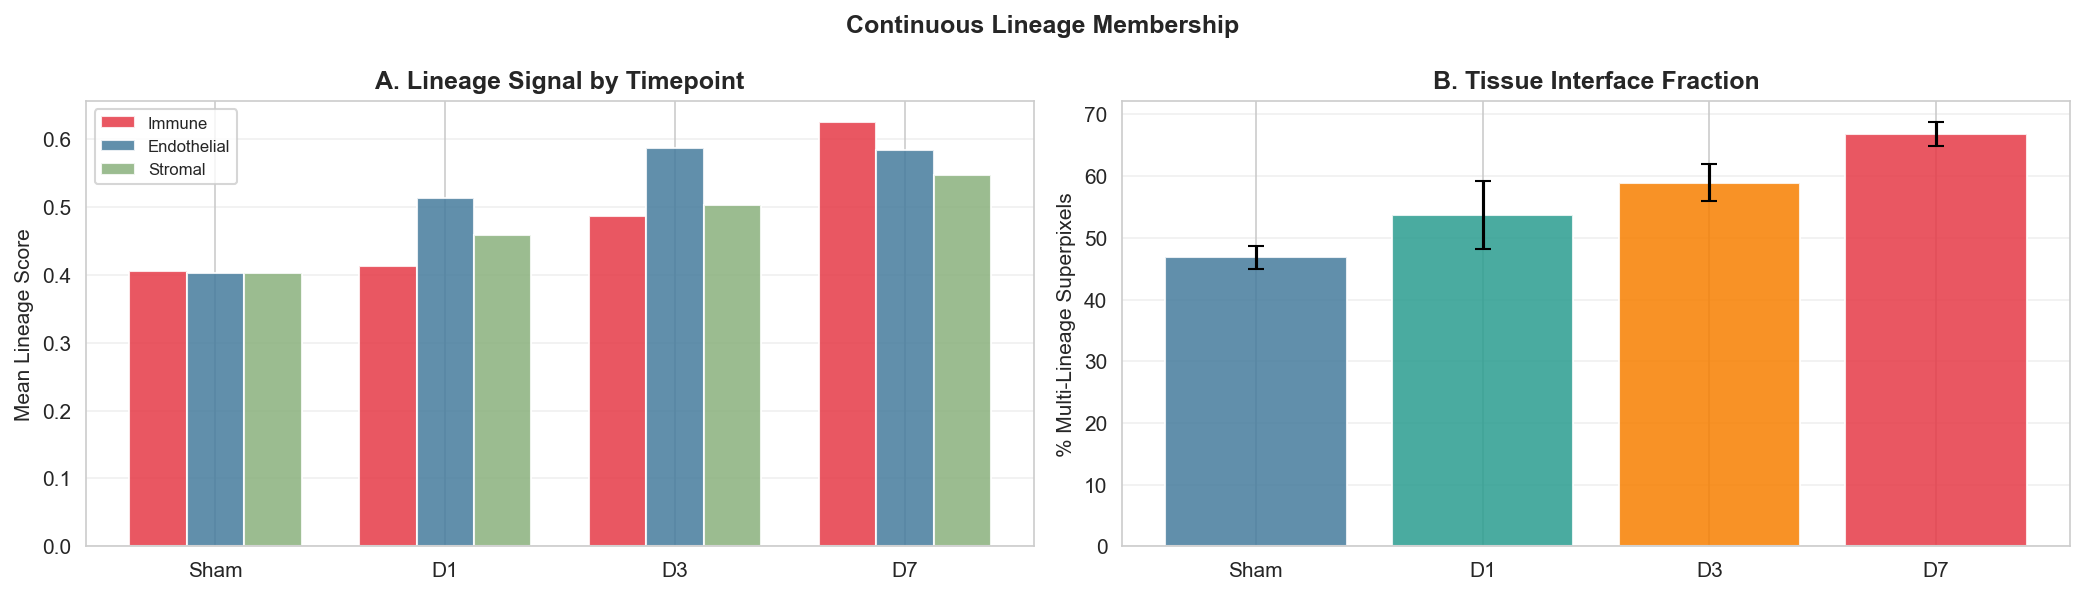

In [9]:
# --- 2d. Lineage composition and interface fraction ---
lineage_cols = [c for c in roi_abundances.columns if c.startswith('lineage_') and c.endswith('_mean')]

if lineage_cols and 'mixed_fraction' in roi_abundances.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # Panel A: Mean lineage scores by timepoint
    mouse_agg = roi_abundances.groupby(['timepoint', 'mouse'])[lineage_cols].mean().reset_index()
    mouse_agg['timepoint'] = pd.Categorical(mouse_agg['timepoint'], categories=TP_ORDER, ordered=True)
    mouse_mean = mouse_agg.groupby('timepoint')[lineage_cols].mean()
    
    x = np.arange(len(mouse_mean))
    width = 0.25
    lineage_colors = {'lineage_immune_mean': '#E63946', 'lineage_endothelial_mean': '#457B9D', 'lineage_stromal_mean': '#8AB17D'}
    
    for i, col in enumerate(lineage_cols):
        label = col.replace('lineage_', '').replace('_mean', '').capitalize()
        color = lineage_colors.get(col, f'C{i}')
        ax1.bar(x + i * width - width, mouse_mean[col].values, width,
                label=label, color=color, alpha=0.85, edgecolor='white')
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(mouse_mean.index, fontsize=10)
    ax1.set_ylabel('Mean Lineage Score')
    ax1.set_title('A. Lineage Signal by Timepoint', fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.grid(axis='y', alpha=0.3)
    
    # Panel B: Multi-lineage fraction trend
    mouse_mixed = roi_abundances.groupby(['timepoint', 'mouse'])['mixed_fraction'].mean().reset_index()
    mouse_mixed['timepoint'] = pd.Categorical(mouse_mixed['timepoint'], categories=TP_ORDER, ordered=True)
    
    for tp_idx, tp in enumerate(TP_ORDER):
        vals = mouse_mixed[mouse_mixed['timepoint'] == tp]['mixed_fraction'] * 100
        color = TP_COLORS.get(tp, '#999')
        ax2.bar(tp_idx, vals.mean(), yerr=vals.std() if len(vals) > 1 else 0,
                color=color, capsize=4, alpha=0.85, edgecolor='white')
    
    ax2.set_xticks(range(len(TP_ORDER)))
    ax2.set_xticklabels(TP_ORDER, fontsize=10)
    ax2.set_ylabel('% Multi-Lineage Superpixels')
    ax2.set_title('B. Tissue Interface Fraction', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    fig.suptitle('Continuous Lineage Membership', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print("Lineage columns not found in roi_abundances — re-run differential_abundance_analysis.py")

---
## 3. Differential Abundance: The 15 Config-Defined Cell Types (Layer A)

§1-§2 mapped the tissue; this section asks which of the **15 cell types defined in `config.json`** change across timepoints. Each cell type is defined by a boolean-gating rule (positive AND negative markers) — for example, `neutrophil = CD45+ AND Ly6G+ AND CD31− AND CD34−`. Mouse-level proportions are tested pairwise across timepoints with Hedges' g effect sizes and bootstrap ranges.

**What this section shows.** Which of the 15 cell types rise or fall across Sham → D1 → D3 → D7; cortex-vs-medulla comparisons; a separate lineage rollup view (§3D) that aggregates cell types by lineage family.

**What it does not show.** Spatial reorganization (§4), continuous lineage score shifts (§6), or whether observed changes are normalization artifacts.

**n=2 realities.** Mann-Whitney U at n=2 produces only three p-values (~0.33, 0.67, 1.0) — no comparison can reach α=0.05 regardless of magnitude. Bootstrap ranges reflect ~9 unique resample values and are NOT coverage-bearing intervals. No FDR is claimed. The purpose is effect-size estimation for follow-up design.

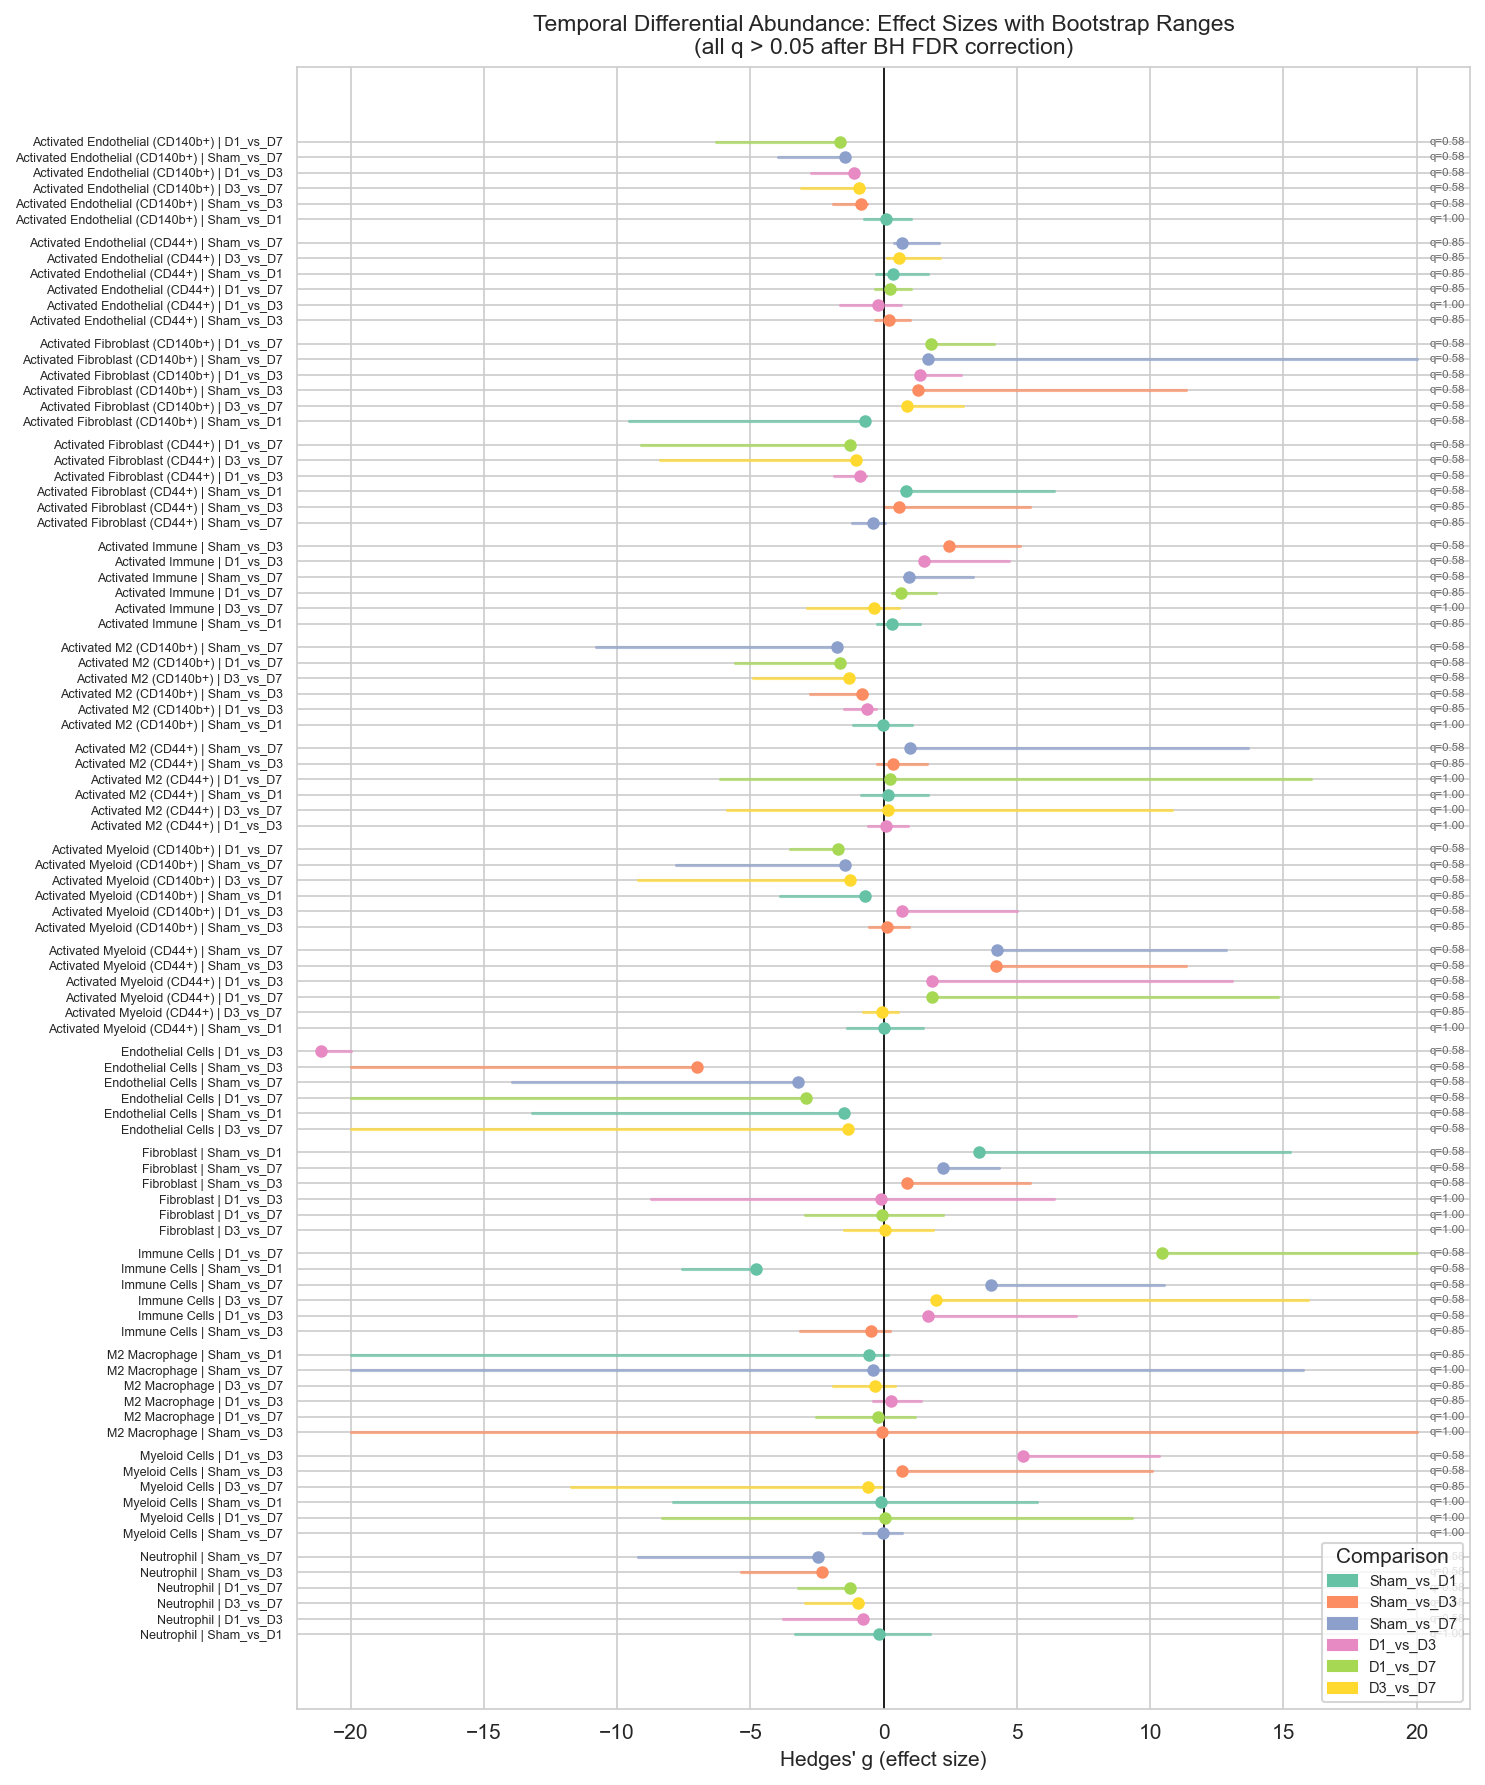

In [10]:
# --- 3A. Forest plot: Hedges' g for the 15 config cell types ---
comparisons = temporal_da['comparison'].unique()
comp_colors = dict(zip(comparisons, sns.color_palette('Set2', len(comparisons))))

# Sort: group by cell type, within each by |hedges_g|
temporal_da['abs_g'] = temporal_da['hedges_g'].abs()
plot_df = temporal_da.sort_values(['cell_type', 'abs_g'], ascending=[True, False])

fig, ax = plt.subplots(figsize=(10, 12))
y_positions = []
y_labels = []
y = 0
prev_ct = None

for _, row in plot_df.iterrows():
    ct = row['cell_type']
    if ct != prev_ct and prev_ct is not None:
        y += 0.5  # gap between cell types
    prev_ct = ct

    color = comp_colors[row['comparison']]
    ci_lo = row['bootstrap_range_min'] if not np.isnan(row['bootstrap_range_min']) else row['hedges_g'] - 1
    ci_hi = row['bootstrap_range_max'] if not np.isnan(row['bootstrap_range_max']) else row['hedges_g'] + 1

    # Clip extreme CIs for readability
    ci_lo_plot = max(ci_lo, -20)
    ci_hi_plot = min(ci_hi, 20)

    ax.plot([ci_lo_plot, ci_hi_plot], [y, y], color=color, linewidth=1.5, alpha=0.7)
    ax.plot(row['hedges_g'], y, 'o', color=color, markersize=5, zorder=5)

    # q-value annotation
    q_text = f"q={row['p_value_fdr']:.2f}" if not np.isnan(row['p_value_fdr']) else 'q=NA'
    ax.text(20.5, y, q_text, fontsize=5.5, va='center', color='#666')

    y_positions.append(y)
    y_labels.append(f"{ct_label(ct)} | {row['comparison']}")
    y += 1

ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=6)
ax.set_xlabel('Hedges\' g (effect size)', fontsize=10)
ax.set_title('Temporal Differential Abundance: Effect Sizes with Bootstrap Ranges\n'
             '(all q > 0.05 after BH FDR correction)', fontsize=11)
ax.set_xlim(-22, 22)
ax.invert_yaxis()

legend_handles = [mpatches.Patch(color=c, label=comp) for comp, c in comp_colors.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=7, title='Comparison')
plt.tight_layout()
plt.show()

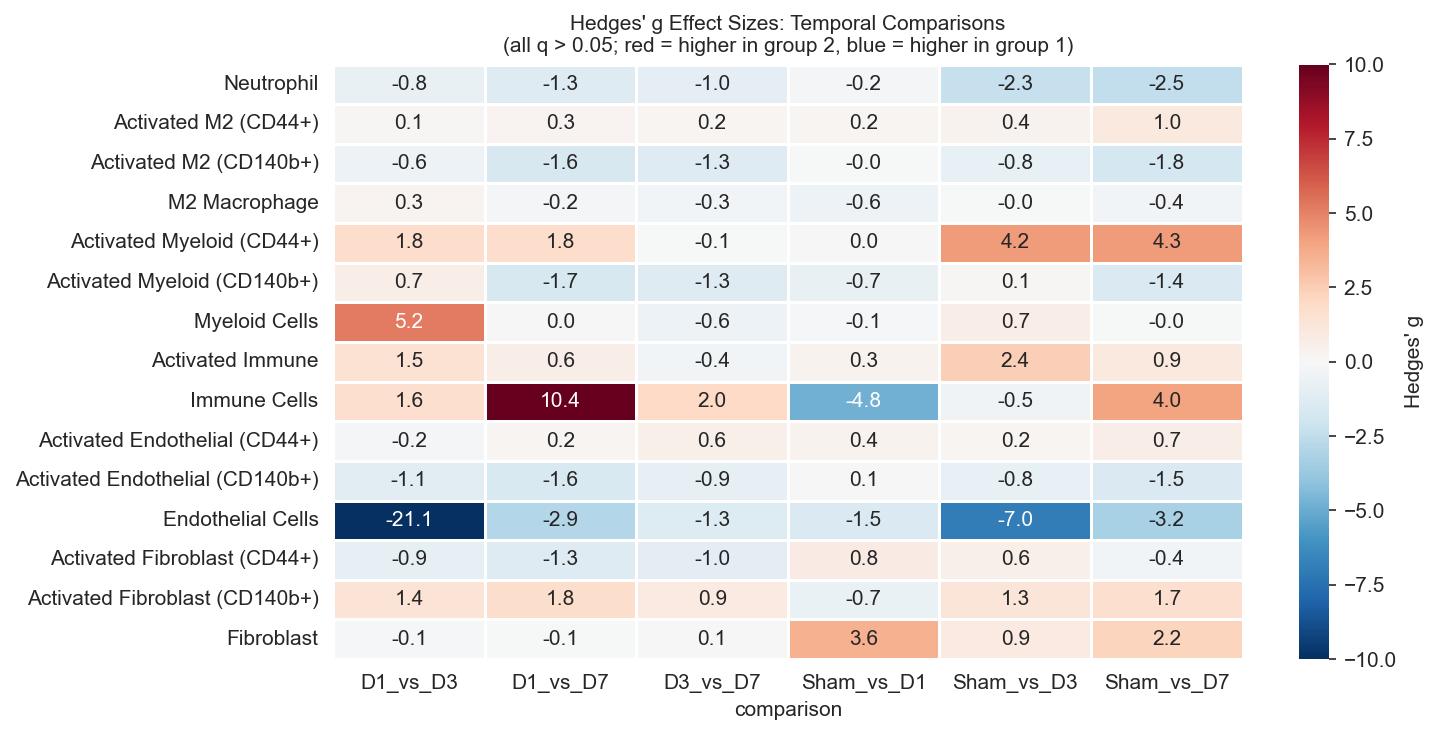

In [11]:
# --- 3B. Effect size heatmap across the 15 config cell types × 6 pairwise contrasts ---
pivot = temporal_da.pivot_table(index='cell_type', columns='comparison',
                                values='hedges_g', aggfunc='first')
# Reorder
pivot = pivot.reindex(index=[ct for ct in CT_ORDER if ct in pivot.index])
pivot_labels = pivot.rename(index=ct_label)

fig, ax = plt.subplots(figsize=(10, 5))
vmax = min(abs(pivot.values[np.isfinite(pivot.values)]).max(), 10)
sns.heatmap(pivot_labels, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': "Hedges' g"}, ax=ax)
ax.set_title("Hedges' g Effect Sizes: Temporal Comparisons\n"
             "(all q > 0.05; red = higher in group 2, blue = higher in group 1)",
             fontsize=10)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

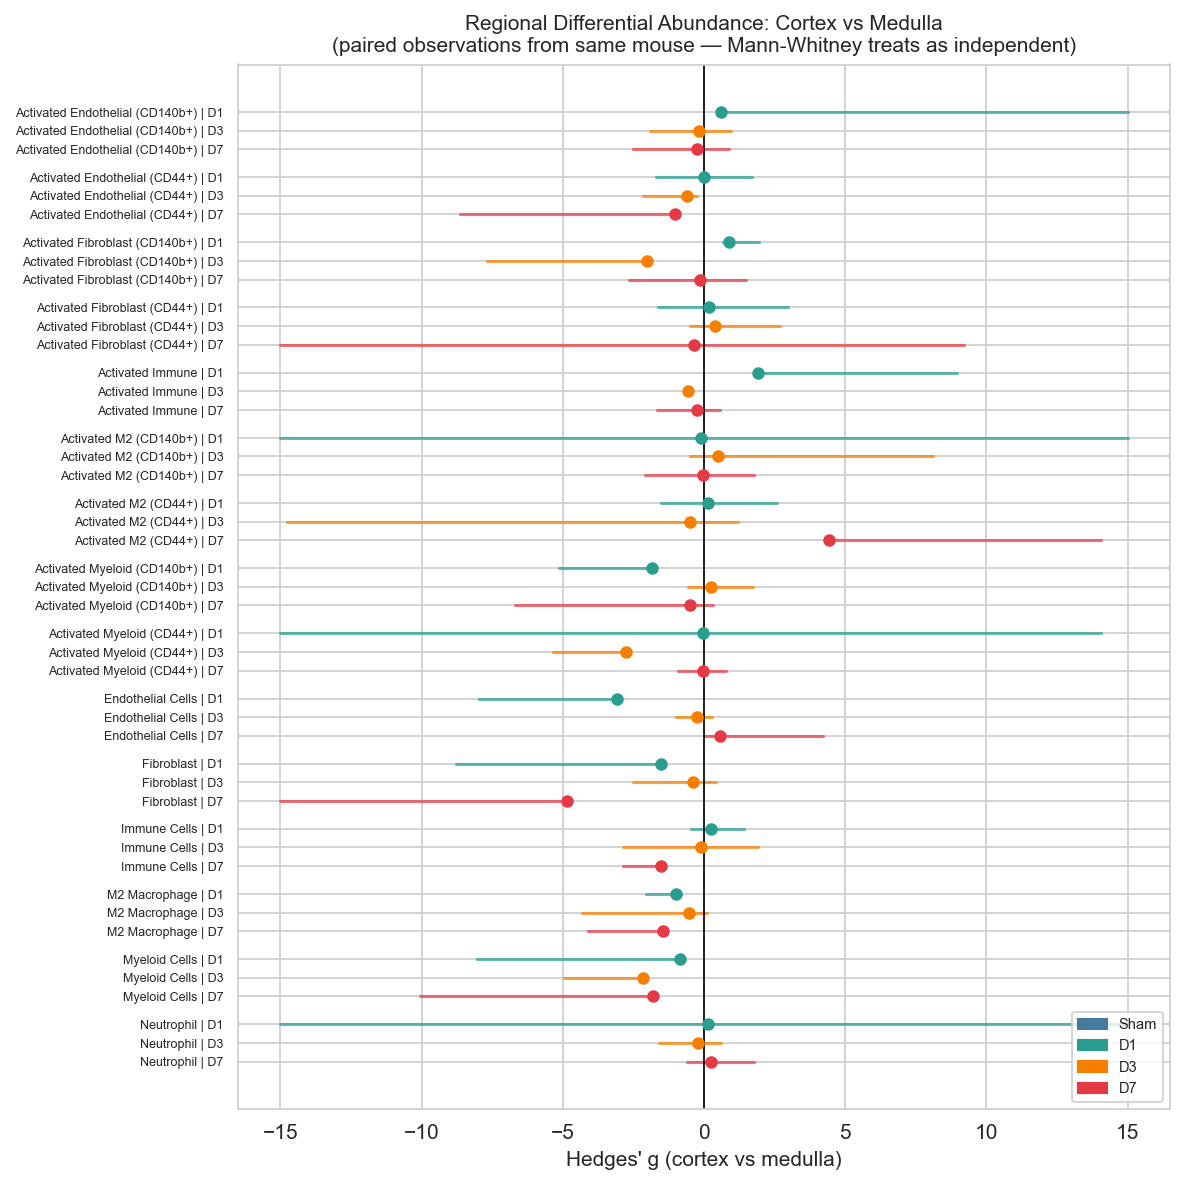

In [12]:
# --- 3C. Regional comparison (cortex vs medulla, Layer A cell types) ---
if len(regional_da) > 0:
    fig, ax = plt.subplots(figsize=(8, 8))
    regional_da_sorted = regional_da.sort_values(['cell_type', 'timepoint'])

    y = 0
    y_positions = []
    y_labels = []
    prev_ct = None

    for _, row in regional_da_sorted.iterrows():
        ct = row['cell_type']
        if ct != prev_ct and prev_ct is not None:
            y += 0.5
        prev_ct = ct

        tp = row['timepoint']
        color = TP_COLORS.get(tp, '#999')
        g = row['hedges_g']
        ci_lo = row.get('bootstrap_range_min', g - 1)
        ci_hi = row.get('bootstrap_range_max', g + 1)
        if pd.isna(ci_lo): ci_lo = g - 1
        if pd.isna(ci_hi): ci_hi = g + 1

        ci_lo_plot = max(ci_lo, -15)
        ci_hi_plot = min(ci_hi, 15)

        ax.plot([ci_lo_plot, ci_hi_plot], [y, y], color=color, linewidth=1.5, alpha=0.7)
        ax.plot(g, y, 'o', color=color, markersize=5, zorder=5)

        y_positions.append(y)
        y_labels.append(f'{ct_label(ct)} | {tp}')
        y += 1

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=6)
    ax.set_xlabel("Hedges' g (cortex vs medulla)", fontsize=10)
    ax.set_title('Regional Differential Abundance: Cortex vs Medulla\n'
                 '(paired observations from same mouse \u2014 Mann-Whitney treats as independent)',
                 fontsize=10)
    ax.invert_yaxis()

    handles = [mpatches.Patch(color=c, label=tp) for tp, c in TP_COLORS.items()]
    ax.legend(handles=handles, loc='lower right', fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print('No regional DA results available.')

In [13]:
# --- 3D. Lineage + subtype rollups (Layer B) ---
# Aggregated view: each of the 15 config cell types rolls up into one of three lineage
# families (immune / endothelial / stromal) and — within immune — into one of four subtypes.
# Computed from the SAME ROI proportions as §3A, just aggregated. Effect sizes here are
# attenuated relative to specific cell types because aggregation averages across activation
# states.

if len(temporal_rollups) > 0:
    # Continuous lineage scores (3 axes, Sham-reference-centered sigmoid)
    lineage_rows = temporal_rollups[temporal_rollups['cell_type'].str.startswith('lineage:')]
    if len(lineage_rows) > 0:
        print('Lineage-level rollups (3 axes, continuous score mean per ROI):')
        print('=' * 80)
        disp = lineage_rows.sort_values('hedges_g', key=abs, ascending=False)[
            ['cell_type', 'comparison', 'mean_1', 'mean_2', 'hedges_g', 'p_value_fdr']
        ].copy()
        disp.columns = ['lineage', 'contrast', 'mean_tp1', 'mean_tp2', 'hedges_g', 'q']
        with pd.option_context('display.float_format', '{:.3f}'.format):
            print(disp.to_string(index=False))
        print()

        # Surface the Sham->D7 trajectory across lineages directly in the cell output,
        # so the all-three-rise pattern is visible without scanning the table.
        sham_d7 = disp[disp['contrast'] == 'Sham_vs_D7'].copy()
        if len(sham_d7) > 0:
            print('Sham -> D7 trajectory across the three lineages:')
            for _, r in sham_d7.iterrows():
                arrow = 'rises' if r['mean_tp1'] < r['mean_tp2'] else 'falls'
                pct = 100 * (r['mean_tp2'] - r['mean_tp1']) / max(abs(r['mean_tp1']), 1e-9)
                print(f'  {r["lineage"]:25s} {r["mean_tp1"]:.3f} -> {r["mean_tp2"]:.3f}  ({arrow} {pct:+.1f}%, |g|={abs(r["hedges_g"]):.2f})')
            n_rising = int((sham_d7['mean_tp1'] < sham_d7['mean_tp2']).sum())
            n_total = len(sham_d7)
            if n_rising == n_total:
                print(f'  -> All {n_total}/{n_total} lineages rise Sham->D7. The §6 reading must')
                print('     account for this: closed-simplex CLR on these scores will reshuffle')
                print('     compositional fractions geometrically when multiple components rise')
                print('     together. Family C in §6 is the non-CLR-coupled cross-check.')
            else:
                print(f'  -> {n_rising}/{n_total} lineages rise Sham->D7.')
        print()
        print('Continuous lineage means use the Sham-reference-centered sigmoid')
        print('(Sham-pooled per-mouse 60th-percentile centering, experiment-wide IQR scale).')
        print('The temporal interface analysis (§6) operates on these scores and cross-checks')
        print('them against an independent raw-marker Sham-reference percentile path.')
        print()

    # Subtype rollups (within-immune refinement)
    subtype_rows = temporal_rollups[temporal_rollups['cell_type'].str.startswith('subtype_')]
    if len(subtype_rows) > 0:
        print('Subtype-level rollups (within immune lineage):')
        print('=' * 80)
        disp = subtype_rows.sort_values('hedges_g', key=abs, ascending=False)[
            ['cell_type', 'comparison', 'mean_1', 'mean_2', 'hedges_g', 'p_value_fdr']
        ].copy()
        disp.columns = ['subtype', 'contrast', 'prop_tp1', 'prop_tp2', 'hedges_g', 'q']
        with pd.option_context('display.float_format', '{:.3f}'.format):
            print(disp.to_string(index=False))
else:
    print('temporal_lineage_rollups.csv not found — re-run differential_abundance_analysis.py')


Lineage-level rollups (3 axes, continuous score mean per ROI):
            lineage   contrast  mean_tp1  mean_tp2  hedges_g     q
    lineage:stromal Sham_vs_D7     0.402     0.547    -4.836 0.400
lineage:endothelial Sham_vs_D3     0.403     0.586    -2.906 0.400
lineage:endothelial Sham_vs_D7     0.403     0.583    -2.624 0.400
lineage:endothelial Sham_vs_D1     0.403     0.513    -2.433 0.400
     lineage:immune   D1_vs_D7     0.413     0.624    -2.122 0.400
     lineage:immune Sham_vs_D7     0.405     0.624    -2.013 0.400
    lineage:stromal Sham_vs_D3     0.402     0.502    -1.922 0.400
     lineage:immune   D1_vs_D3     0.413     0.486    -1.844 0.400
     lineage:immune   D3_vs_D7     0.486     0.624    -1.508 0.400
     lineage:immune Sham_vs_D3     0.405     0.486    -1.369 0.400
    lineage:stromal   D1_vs_D7     0.459     0.547    -1.341 0.400
lineage:endothelial   D1_vs_D3     0.513     0.586    -1.007 0.400
lineage:endothelial   D1_vs_D7     0.513     0.583    -0.906 0.400

### §3D bridge — the load-bearing observation

The lineage rollups above show a single pattern: **all three continuous lineage scores rise Sham→D7** (immune +54%, endothelial +45%, stromal +36% in mouse-level means). This is the observation that drives the §6 reading of the candidate finding:

- The trajectory itself is visualized in §2 panel A ("Lineage Signal by Timepoint") — the same numbers, plotted as Sham vs D7 means.
- §6's Family A operates on a closed-simplex CLR transform of these scores. When multiple lineage scores rise together, the relative composition must reshuffle geometrically — independent of any per-cell-type biological event.
- §6's Family C (compartment activation) is the non-CLR-coupled cross-check on whether the underlying signal is broad activation. It is.

The §3 capstone table below ranks the Layer A discrete-cell-type findings; §6 then reframes the same biology through the three pre-registered endpoint families with Bayesian shrinkage and explicit normalization sensitivity.


In [14]:
# --- §3 capstone: top Layer A findings cross-referenced with INDRA + self-enrichment ---
# This table draws the top 10 differential-abundance findings (15 config cell
# types) and joins them with INDRA-grounded biological context and the §4
# spatial self-enrichment scores. It closes §3 with a single descriptive
# scoreboard before §4 turns to spatial neighborhood structure.

# Compute self-enrichment locally (§4 introduces this surface; we preview it
# here for the §3 capstone joint table).
_self_enrich = temporal_enrich[
    temporal_enrich['focal_cell_type'] == temporal_enrich['neighbor_cell_type']
].copy()
da_annotated = temporal_da.copy()
da_annotated['abs_g'] = da_annotated['hedges_g'].abs()
da_top = da_annotated.nlargest(10, 'abs_g')

# Cross-reference with INDRA annotations
rows_out = []
for _, row in da_top.iterrows():
    ct = row['cell_type']
    indra_match = indra_annot[
        (indra_annot['cell_type'] == ct) &
        (indra_annot['finding_type'] == 'differential_abundance')
    ]
    tier = indra_match['indra_context_tier'].values[0] if len(indra_match) > 0 else '-'
    n_evidence = indra_match['indra_evidence_count'].values[0] if len(indra_match) > 0 else 0
    aki = indra_match['aki_gene_association'].values[0] if len(indra_match) > 0 else False

    self_e = _self_enrich[_self_enrich['focal_cell_type'] == ct]['enrichment_score'].mean()

    rows_out.append({
        'Cell Type': ct_label(ct),
        'Comparison': row['comparison'],
        'Hedges g': f"{row['hedges_g']:.2f}",
        'Bootstrap range': f"[{row['bootstrap_range_min']:.1f}, {row['bootstrap_range_max']:.1f}]",
        'q-value': f"{row['p_value_fdr']:.2f}",
        'INDRA Tier': tier,
        'INDRA Evidence': int(n_evidence) if not pd.isna(n_evidence) else 0,
        'AKI Assoc.': 'Yes' if aki else 'No',
        'Self-Enrichment': f'{self_e:.2f}x' if not np.isnan(self_e) else '-',
    })

evidence_df = pd.DataFrame(rows_out)
print('§3 capstone: Top 10 Layer A findings by |hedges_g|, joined with INDRA + self-enrichment')
print('=' * 100)
print(evidence_df.to_string(index=False))
print('\nAll q > 0.05 (no FDR-significant findings at n=2). §6 reframes these effects')
print('through the temporal-interface endpoint families with Bayesian shrinkage.')


§3 capstone: Top 10 Layer A findings by |hedges_g|, joined with INDRA + self-enrichment
                Cell Type Comparison Hedges g Bootstrap range q-value INDRA Tier  INDRA Evidence AKI Assoc. Self-Enrichment
        Endothelial Cells   D1_vs_D3   -21.11  [-36.9, -21.1]    0.58     medium              18         No           1.55x
             Immune Cells   D1_vs_D7    10.43    [10.4, 24.2]    0.58          -               0         No           1.43x
        Endothelial Cells Sham_vs_D3    -7.00   [-35.6, -7.0]    0.58     medium              18         No           1.55x
            Myeloid Cells   D1_vs_D3     5.22     [5.2, 10.3]    0.58     medium              35         No           1.41x
             Immune Cells Sham_vs_D1    -4.80    [-7.6, -4.8]    0.58          -               0         No           1.43x
Activated Myeloid (CD44+) Sham_vs_D7     4.27     [4.3, 12.8]    0.58     medium              35        Yes           3.75x
Activated Myeloid (CD44+) Sham_vs_D3     4.2

---
## 4. Spatial Neighborhood Architecture

Who sits next to whom. For each focal cell type in each ROI, we examine the 10 nearest neighboring superpixels and count what types they are, comparing to a permutation null (1,000 global shuffles of cell type labels within the ROI; Phipson-Smyth pseudocount). Enrichment ratios > 1 mean "this pair co-locates more than chance"; < 1 means avoidance.

**Self-enrichment caveat.** Cell types defined by overlapping markers (e.g., `activated_myeloid_cd44` and `activated_endothelial_cd44` both require CD44⁺) share expression space, and therefore physical space. Diagonal self-enrichment conflates genuine spatial clustering with marker-sharing circularity. Cross-type (off-diagonal) associations are more interpretable.

**Mouse-of-mouse basis.** These neighborhood enrichments are the mouse-of-mouse (support-gated `aggregate_strata`) basis, which retires ROI-level pseudoreplication; the shipped ROI-level CSVs remain a documented reproduction anchor. Descriptive summaries at n=2 mice per timepoint — no significance testing.

**What this section shows.** Which cell-type pairs co-localize, how those associations shift across timepoints, and cortex-vs-medulla differences in neighborhood structure.

**What it does not show.** Continuous-lineage neighborhood dynamics — those live in Family B (kidney notebook Part 2.5). Nor does co-localization imply functional interaction; it is spatial coincidence.

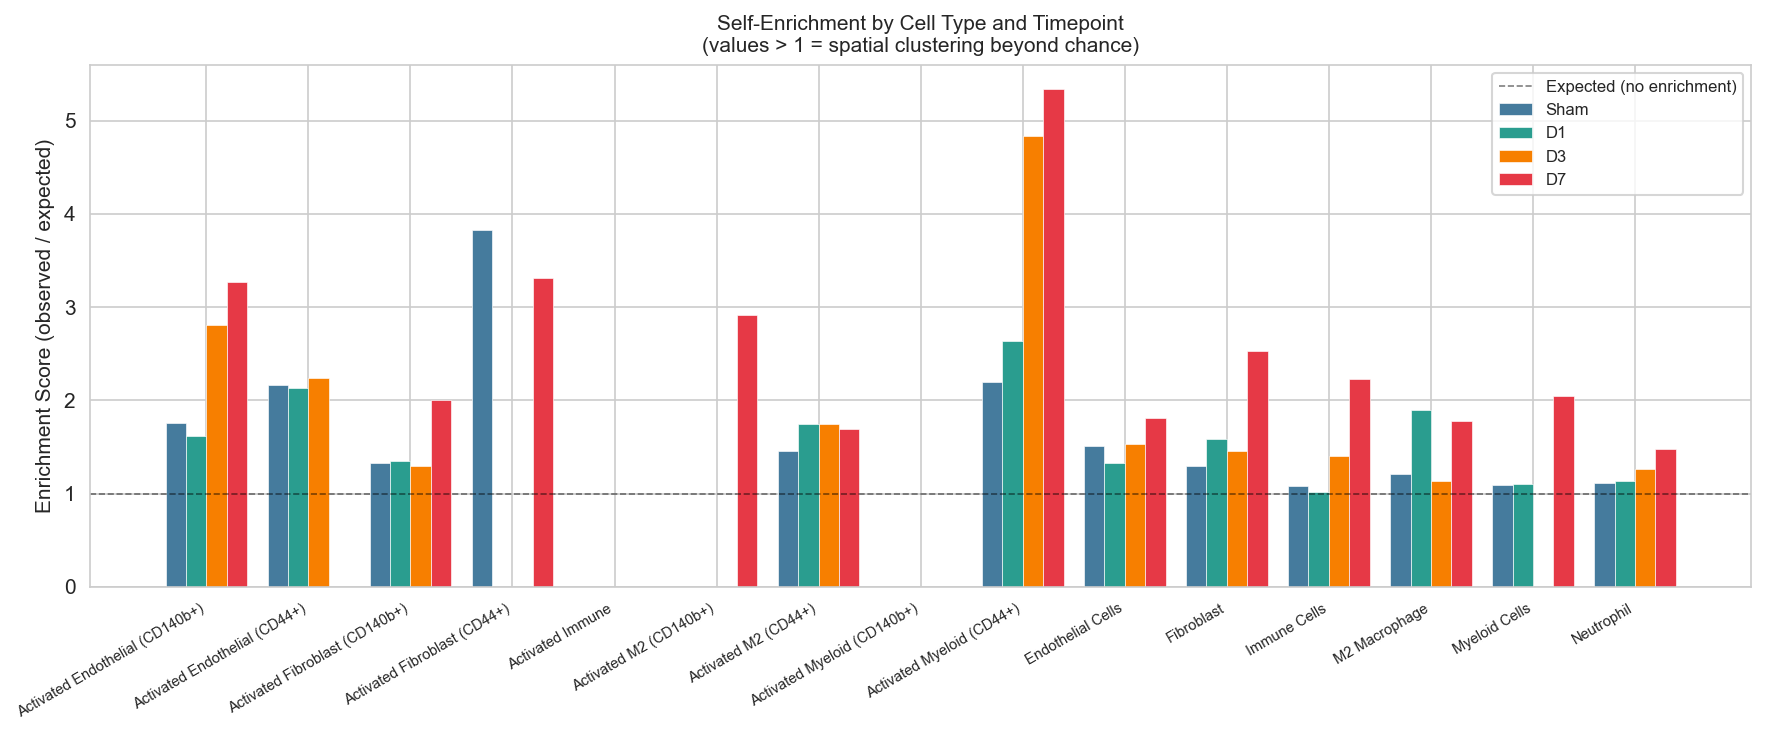

Self-enrichment range: 1.01x – 5.34x (all cell types cluster with themselves)


In [15]:
# --- 4a. Self-enrichment temporal dynamics ---
self_enrich = temporal_enrich[
    temporal_enrich['focal_cell_type'] == temporal_enrich['neighbor_cell_type']
].copy()
self_enrich['timepoint'] = pd.Categorical(self_enrich['timepoint'],
                                          categories=TP_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(12, 5))
ct_list = sorted(self_enrich['focal_cell_type'].unique())
x = np.arange(len(ct_list))
width = 0.2

for i, tp in enumerate(TP_ORDER):
    tp_data = self_enrich[self_enrich['timepoint'] == tp]
    vals = [tp_data[tp_data['focal_cell_type'] == ct]['enrichment_score'].values[0]
            if len(tp_data[tp_data['focal_cell_type'] == ct]) > 0 else 0
            for ct in ct_list]
    bars = ax.bar(x + i * width, vals, width, color=TP_COLORS[tp],
                  label=tp, edgecolor='white', linewidth=0.3)

ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5,
           label='Expected (no enrichment)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([ct_label(ct) for ct in ct_list], fontsize=7, rotation=30, ha='right')
ax.set_ylabel('Enrichment Score (observed / expected)')
ax.set_title('Self-Enrichment by Cell Type and Timepoint\n'
             '(values > 1 = spatial clustering beyond chance)', fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Self-enrichment range: {self_enrich["enrichment_score"].min():.2f}x \u2013 '
      f'{self_enrich["enrichment_score"].max():.2f}x '
      f'(all cell types cluster with themselves)')

/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/seaborn/utils.py:84: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_31820/1770094215.py:34: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


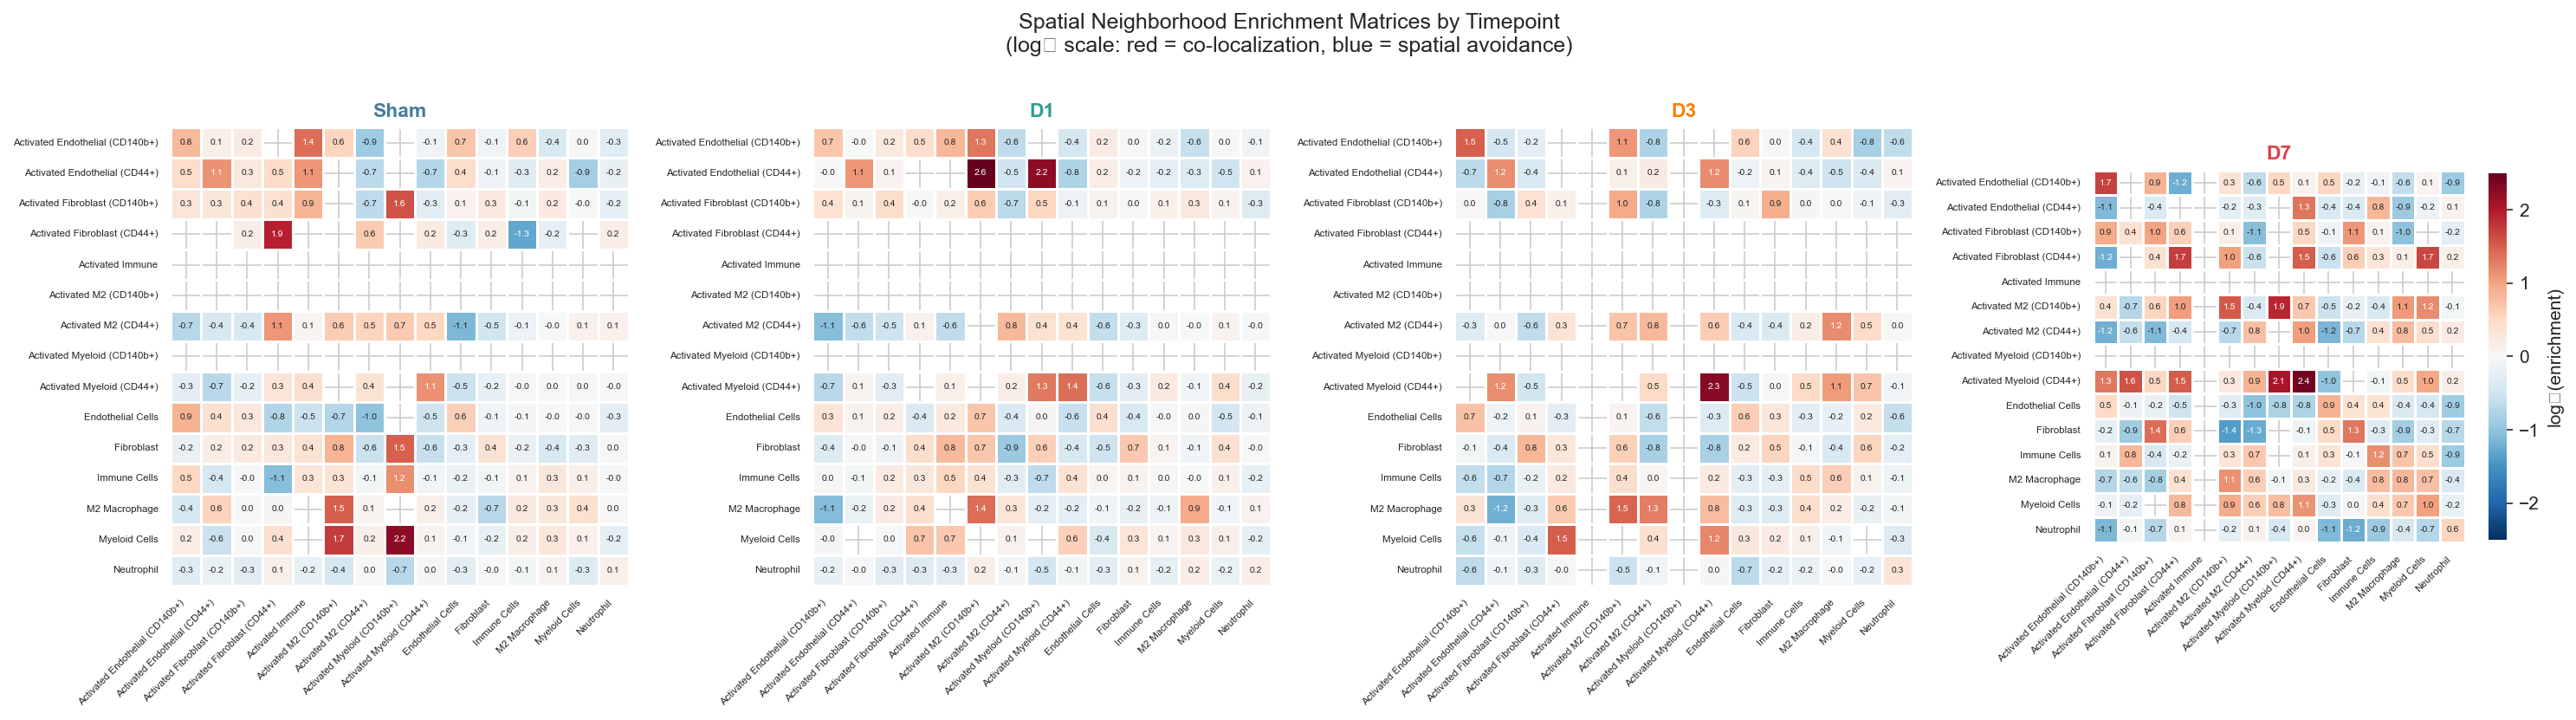

In [16]:
# --- 4b. Full enrichment matrices by timepoint ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

all_cts = sorted(temporal_enrich['focal_cell_type'].unique())
ct_short = [ct_label(ct) for ct in all_cts]

for idx, tp in enumerate(TP_ORDER):
    ax = axes[idx]
    tp_data = temporal_enrich[temporal_enrich['timepoint'] == tp]

    matrix = pd.DataFrame(np.nan, index=all_cts, columns=all_cts)
    for _, row in tp_data.iterrows():
        matrix.loc[row['focal_cell_type'], row['neighbor_cell_type']] = row['log2_enrichment']

    matrix_display = matrix.copy()
    matrix_display.index = ct_short
    matrix_display.columns = ct_short

    vmax = 2.5
    sns.heatmap(matrix_display, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
                square=True, cbar=idx == 3,
                cbar_kws={'label': 'log\u2082(enrichment)', 'shrink': 0.8} if idx == 3 else {},
                ax=ax, annot_kws={'fontsize': 5})
    ax.set_title(tp, fontsize=11, fontweight='bold', color=TP_COLORS[tp])
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=5.5, rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=5.5)
    if idx > 0:
        ax.set_ylabel('')

fig.suptitle('Spatial Neighborhood Enrichment Matrices by Timepoint\n'
             '(log\u2082 scale: red = co-localization, blue = spatial avoidance)',
             fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

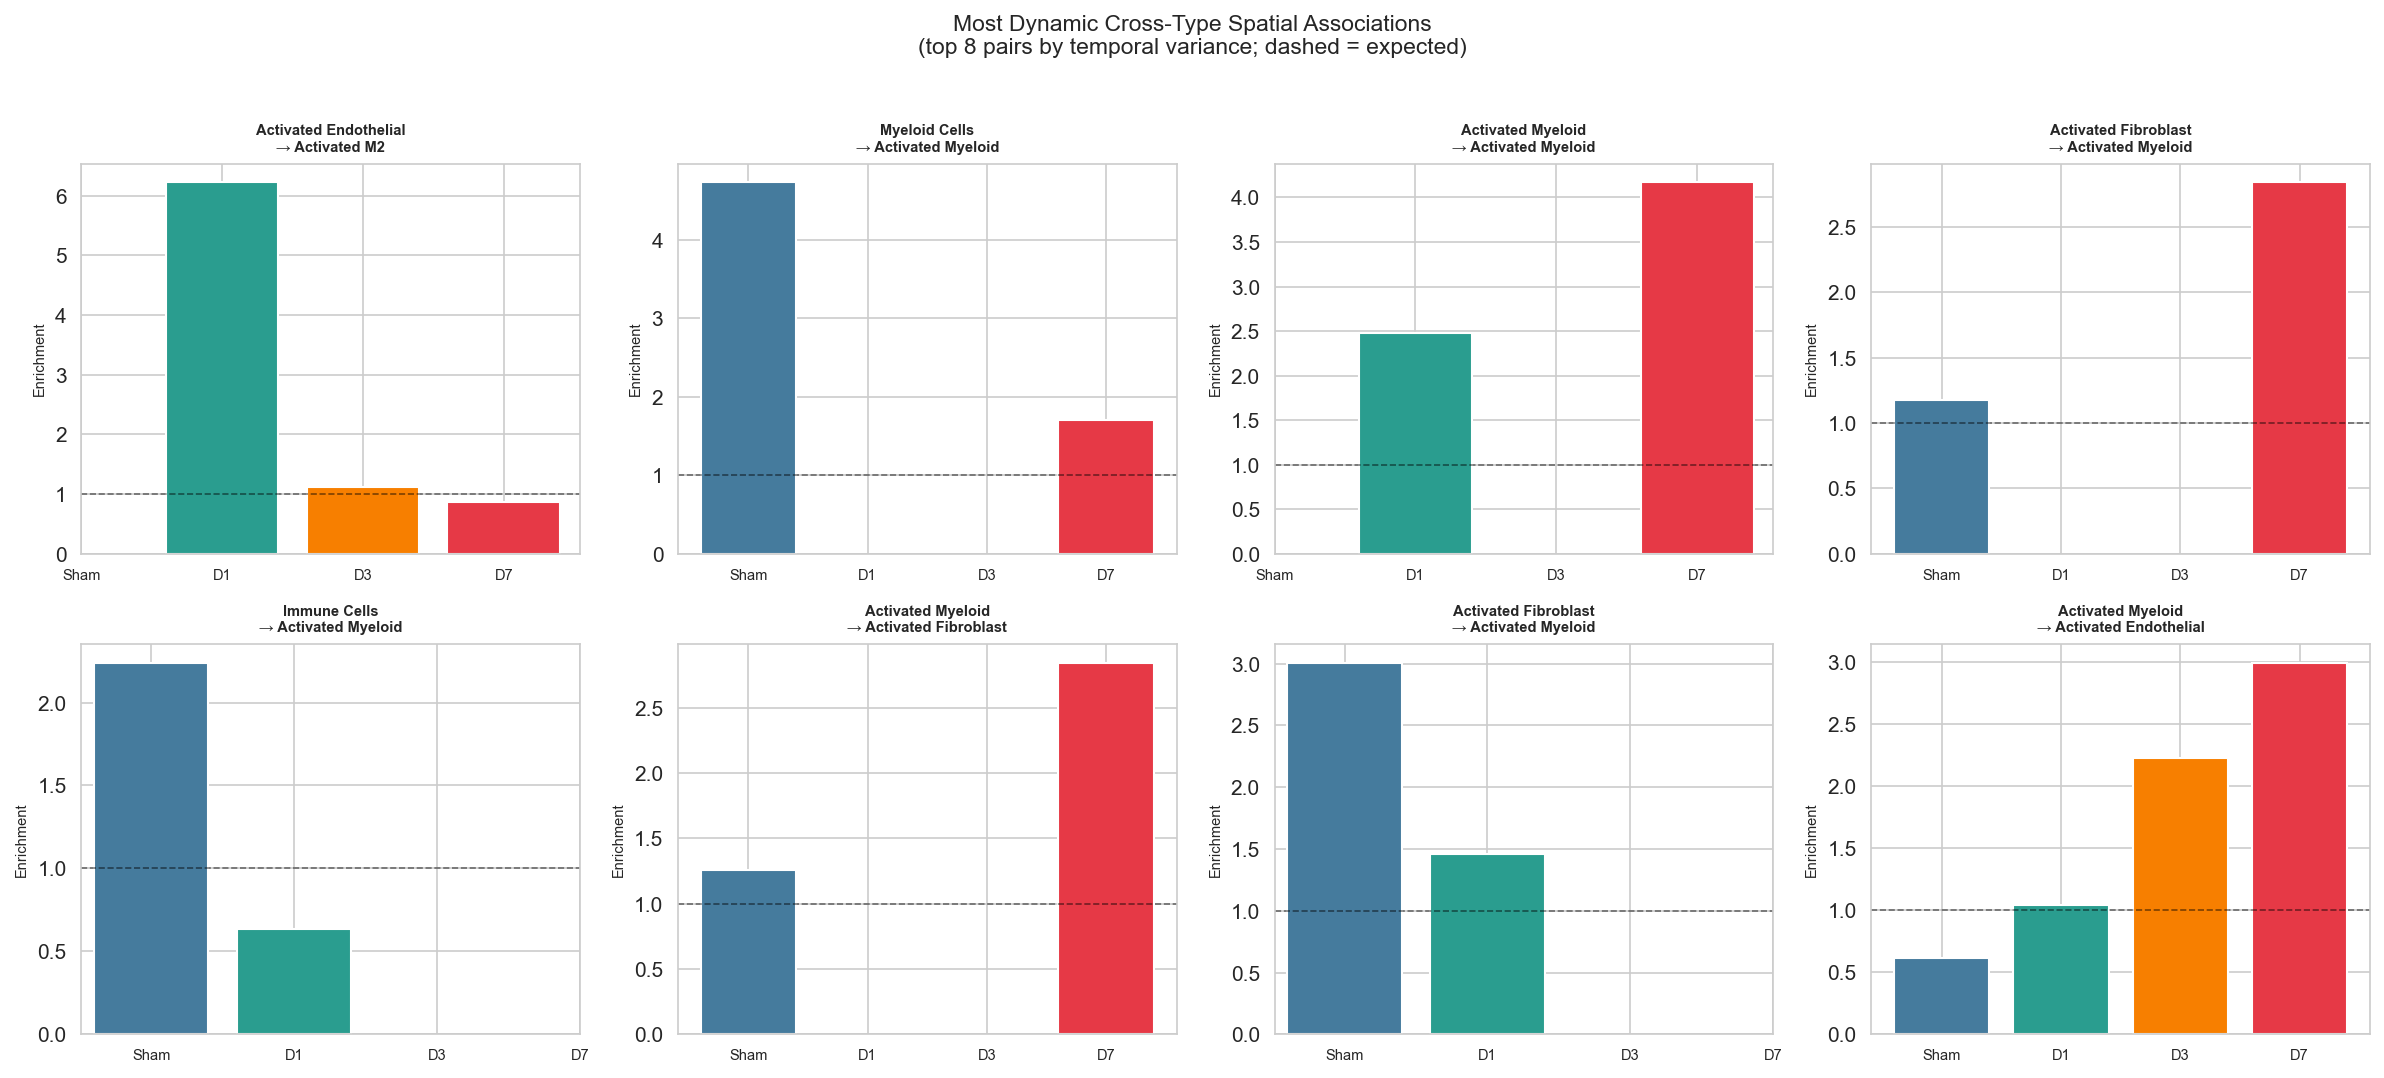

In [17]:
# --- 4c. Key temporal dynamics of cross-type pairs ---
cross_enrich = temporal_enrich[
    temporal_enrich['focal_cell_type'] != temporal_enrich['neighbor_cell_type']
].copy()

# Find most dynamic pairs (largest temporal variance)
pair_var = cross_enrich.groupby(
    ['focal_cell_type', 'neighbor_cell_type']
)['enrichment_score'].var().reset_index()
pair_var.columns = ['focal', 'neighbor', 'variance']
top_pairs = pair_var.nlargest(8, 'variance')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, (_, pair) in enumerate(top_pairs.iterrows()):
    ax = axes[i]
    mask = ((cross_enrich['focal_cell_type'] == pair['focal']) &
            (cross_enrich['neighbor_cell_type'] == pair['neighbor']))
    pair_data = cross_enrich[mask].sort_values('timepoint')

    for _, row in pair_data.iterrows():
        tp = row['timepoint']
        ax.bar(TP_ORDER.index(tp), row['enrichment_score'],
               color=TP_COLORS.get(tp, '#999'), edgecolor='white')

    ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xticks(range(4))
    ax.set_xticklabels(TP_ORDER, fontsize=7)
    focal_short = ct_label(pair['focal']).split('(')[0].strip()
    neighbor_short = ct_label(pair['neighbor']).split('(')[0].strip()
    ax.set_title(f'{focal_short}\n\u2192 {neighbor_short}',
                 fontsize=7, fontweight='bold')
    ax.set_ylabel('Enrichment', fontsize=7)

fig.suptitle('Most Dynamic Cross-Type Spatial Associations\n'
             '(top 8 pairs by temporal variance; dashed = expected)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/seaborn/utils.py:84: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()


/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


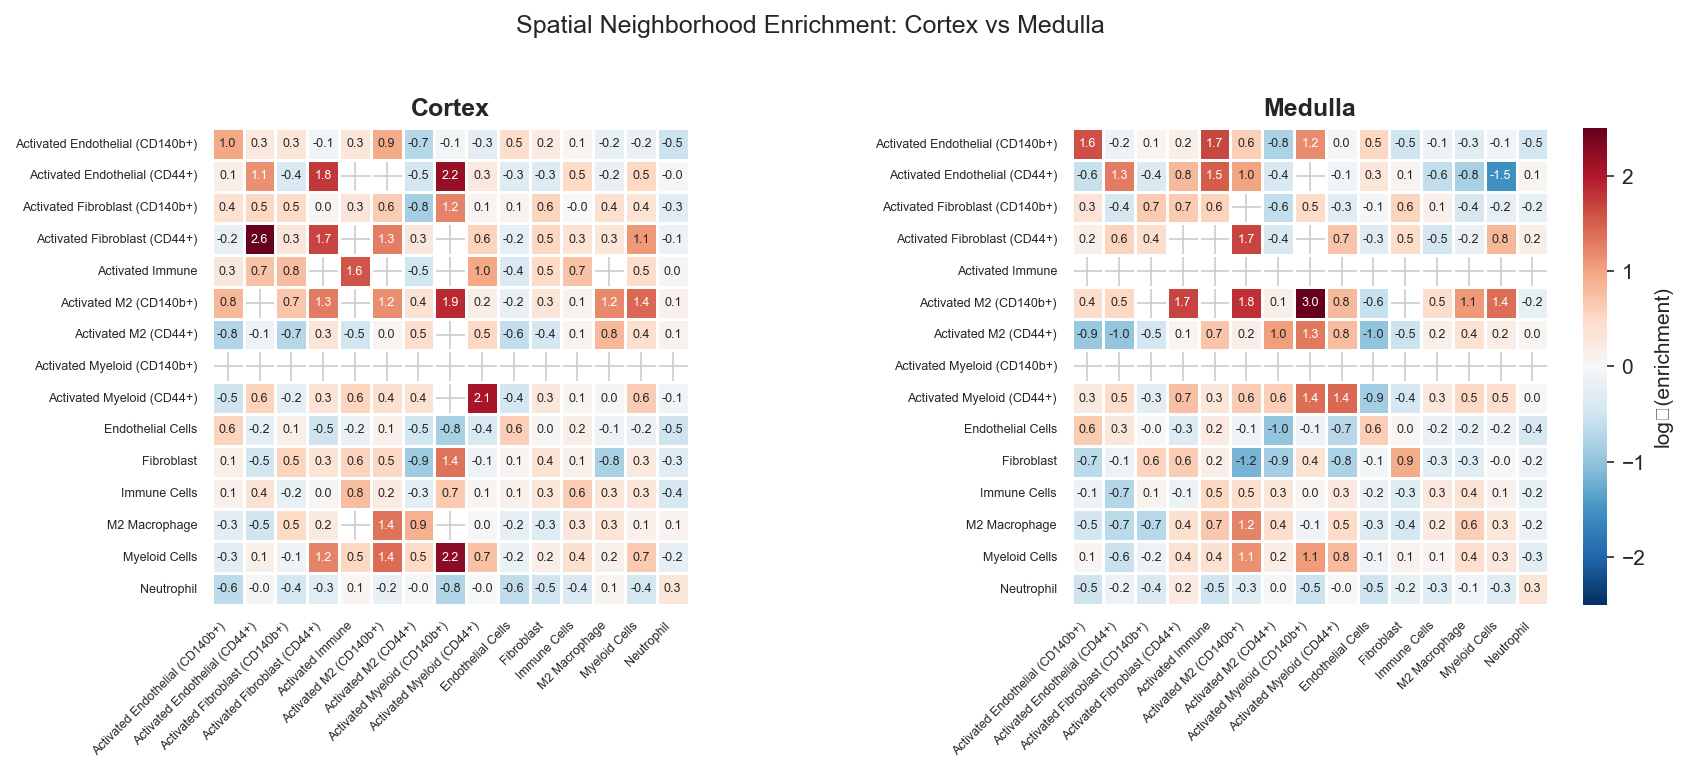

In [18]:
# --- 4d. Regional enrichment comparison ---
regions = sorted(regional_enrich['region'].unique())
all_cts_r = sorted(regional_enrich['focal_cell_type'].unique())
ct_short_r = [ct_label(ct) for ct in all_cts_r]

n_regions = len(regions)
fig, axes = plt.subplots(1, n_regions, figsize=(6 * n_regions, 5))
if n_regions == 1:
    axes = [axes]

for idx, region in enumerate(regions):
    ax = axes[idx]
    reg_data = regional_enrich[regional_enrich['region'] == region]

    matrix = pd.DataFrame(np.nan, index=all_cts_r, columns=all_cts_r)
    for _, row in reg_data.iterrows():
        if 'log2_enrichment' in row:
            matrix.loc[row['focal_cell_type'], row['neighbor_cell_type']] = row['log2_enrichment']
        else:
            val = np.log2(row['enrichment_score']) if row['enrichment_score'] > 0 else np.nan
            matrix.loc[row['focal_cell_type'], row['neighbor_cell_type']] = val

    matrix_display = matrix.copy()
    matrix_display.index = ct_short_r
    matrix_display.columns = ct_short_r

    vmax = 2.5
    sns.heatmap(matrix_display, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
                square=True, cbar=idx == n_regions - 1,
                cbar_kws={'label': 'log\u2082(enrichment)'} if idx == n_regions - 1 else {},
                ax=ax, annot_kws={'fontsize': 6})
    ax.set_title(region, fontsize=12, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    if idx > 0:
        ax.set_ylabel('')

fig.suptitle('Spatial Neighborhood Enrichment: Cortex vs Medulla',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Knowledge Graph Context

Which interactions among the panel markers are already documented in the literature? We queried INDRA/CoGEx, a graph that aggregates ~35 million causal relationships mined from the biomedical literature, for two things: (a) which panel markers connect to each other mechanistically, and (b) which connect to acute kidney injury as a disease concept. 117 intra-panel edges span the 8 groundable genes (Ly6g, a murine-specific marker, lacks adequate coverage).

This is **literature context**, not validation. The knowledge graph tells us what has been published, not whether a specific spatial pattern we measure in this cohort reflects that mechanism. A shared upstream regulator (TGF-β, VEGF) is useful discussion color — it suggests where in the regulatory network a finding sits — but does not confirm any specific effect size.

**Circularity to watch for.** Cell types defined by marker co-expression automatically have INDRA edges between those markers — neutrophil self-enrichment has an ITGAM-Ly6G relationship because we *defined* neutrophils as CD11b⁺/Ly6G⁺. Cross-type associations whose markers come from different biological axes are more informative than same-axis associations.

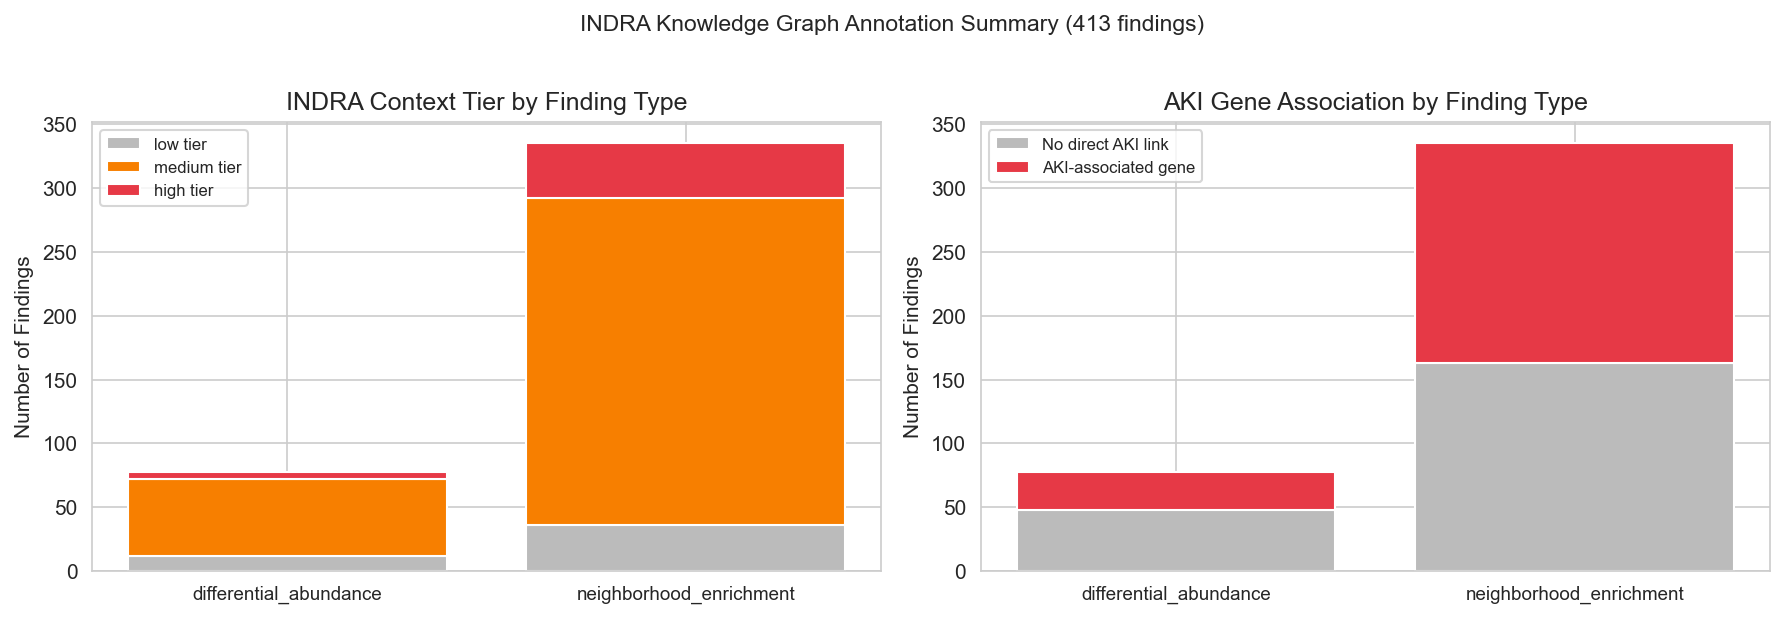

Total annotated findings: 413
  Medium-tier INDRA context: 316
  Low-tier INDRA context: 48
  AKI gene association: 202


In [19]:
# --- 5a. Finding annotation summary ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# By finding type and INDRA tier
ax = axes[0]
tier_counts = indra_annot.groupby(['finding_type', 'indra_context_tier']).size().unstack(fill_value=0)
tier_colors = {'medium': '#F77F00', 'low': '#BBBBBB', 'high': '#E63946'}
bottom = np.zeros(len(tier_counts))
for tier in ['low', 'medium', 'high']:
    if tier in tier_counts.columns:
        vals = tier_counts[tier].values
        ax.bar(range(len(tier_counts)), vals, bottom=bottom,
               color=tier_colors.get(tier, '#999'), label=f'{tier} tier',
               edgecolor='white')
        bottom += vals

ax.set_xticks(range(len(tier_counts)))
ax.set_xticklabels(tier_counts.index, fontsize=9)
ax.set_ylabel('Number of Findings')
ax.set_title('INDRA Context Tier by Finding Type')
ax.legend(fontsize=8)

# AKI gene association
ax = axes[1]
aki_counts = indra_annot.groupby(['finding_type', 'aki_gene_association']).size().unstack(fill_value=0)
aki_colors = {True: '#E63946', False: '#BBBBBB'}
bottom = np.zeros(len(aki_counts))
for has_aki in [False, True]:
    if has_aki in aki_counts.columns:
        vals = aki_counts[has_aki].values
        label = 'AKI-associated gene' if has_aki else 'No direct AKI link'
        ax.bar(range(len(aki_counts)), vals, bottom=bottom,
               color=aki_colors[has_aki], label=label, edgecolor='white')
        bottom += vals

ax.set_xticks(range(len(aki_counts)))
ax.set_xticklabels(aki_counts.index, fontsize=9)
ax.set_ylabel('Number of Findings')
ax.set_title('AKI Gene Association by Finding Type')
ax.legend(fontsize=8)

plt.suptitle(f'INDRA Knowledge Graph Annotation Summary ({len(indra_annot)} findings)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'Total annotated findings: {len(indra_annot)}')
print(f'  Medium-tier INDRA context: {(indra_annot["indra_context_tier"] == "medium").sum()}')
print(f'  Low-tier INDRA context: {(indra_annot["indra_context_tier"] == "low").sum()}')
print(f'  AKI gene association: {indra_annot["aki_gene_association"].sum()}')

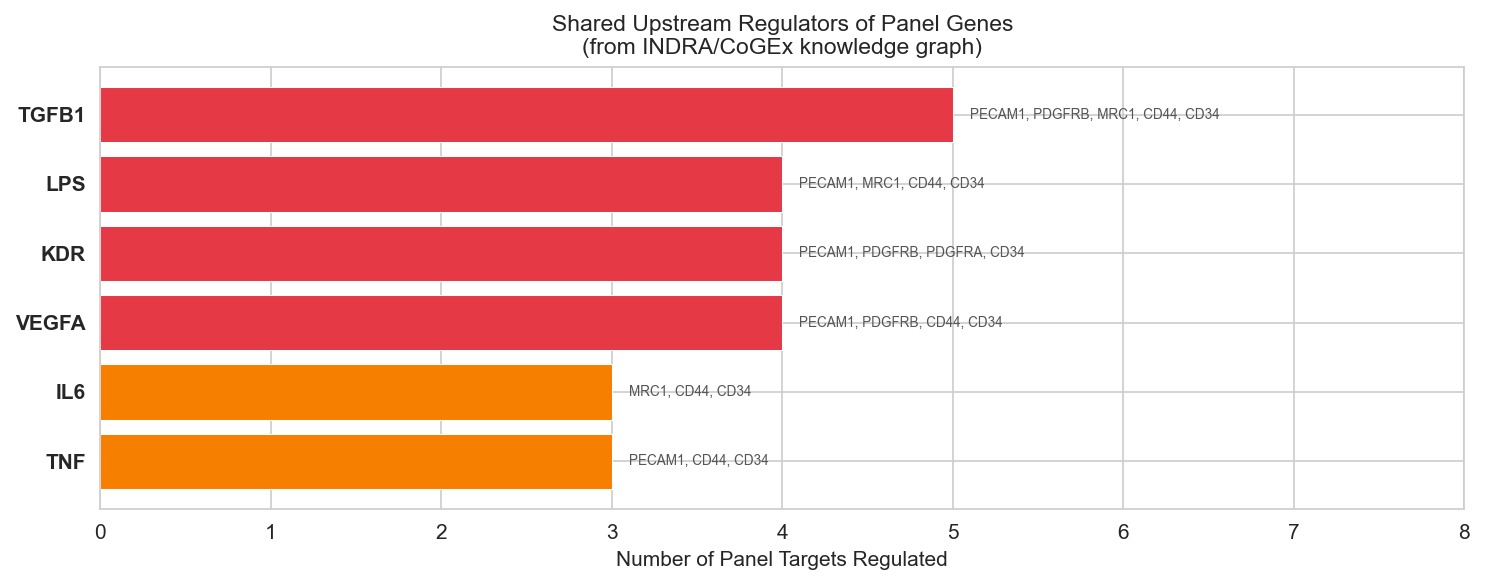

TGFB1: Master regulator of renal fibrosis. Regulates 5/8 panel genes spanning endothelial, stromal, immune, and injury axes.
LPS: Innate immune activation. Relevant to DAMP-mediated sterile inflammation in AKI.
KDR: VEGFR2 — connects VEGF signaling to endothelial and pericyte biology.
VEGFA: Vascular homeostasis and angiogenesis. Regulates both endothelial markers and injury/stromal markers.
IL6: Inflammatory cytokine; CD44 and MRC1 as targets connects injury to resolution.
TNF: Pro-inflammatory cytokine central to AKI pathogenesis.


In [20]:
# --- 5b. Upstream regulator analysis ---
regs = indra_ctx['shared_upstream_regulators']

reg_names = list(regs.keys())
reg_counts = [regs[r]['count'] for r in reg_names]
reg_relevance = [regs[r]['relevance'] for r in reg_names]

# Sort by count
order = np.argsort(reg_counts)[::-1]
reg_names = [reg_names[i] for i in order]
reg_counts = [reg_counts[i] for i in order]
reg_relevance = [reg_relevance[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 4))
colors_reg = ['#E63946' if c >= 4 else '#F77F00' if c >= 3 else '#BBBBBB'
              for c in reg_counts]
bars = ax.barh(range(len(reg_names)), reg_counts, color=colors_reg,
               edgecolor='white', linewidth=0.5)

for i, (name, count) in enumerate(zip(reg_names, reg_counts)):
    targets = regs[name]['targets']
    target_str = ', '.join(targets)
    ax.text(count + 0.1, i, f'{target_str}', fontsize=6.5, va='center', color='#555')

ax.set_yticks(range(len(reg_names)))
ax.set_yticklabels(reg_names, fontsize=10, fontweight='bold')
ax.set_xlabel('Number of Panel Targets Regulated')
ax.set_title('Shared Upstream Regulators of Panel Genes\n'
             '(from INDRA/CoGEx knowledge graph)', fontsize=11)
ax.invert_yaxis()
ax.set_xlim(0, 8)
plt.tight_layout()
plt.show()

# Print relevance
for name, rel in zip(reg_names, reg_relevance):
    print(f'{name}: {rel}')

In [21]:
# --- 5c. Mechanistic narratives cross-referenced with spatial data ---
narratives = indra_ctx['mechanistic_narratives']

print('=== Mechanistic Narratives from INDRA Knowledge Graph ===')
print('(cross-referenced with observed spatial enrichment)\n')

for pair_key, narrative_text in narratives.items():
    # Parse pair key (e.g., 'endothelial_endothelial' or 'macrophage_fibroblast')
    parts = pair_key.split('_')
    mid = len(parts) // 2
    focal_key = '_'.join(parts[:mid])
    neighbor_key = '_'.join(parts[mid:])

    # Try to find matching enrichment data
    enrichment_info = ''
    for _, row in temporal_enrich.iterrows():
        if (focal_key in row['focal_cell_type'] and
            neighbor_key in row['neighbor_cell_type']):
            enrichment_info = (f"  Spatial enrichment at {row['timepoint']}: "
                              f"{row['enrichment_score']:.2f}x "
                              f"(log\u2082={row['log2_enrichment']:.2f})")
            break

    print(f'\u2500\u2500\u2500 {pair_key.replace("_", " ").title()} \u2500\u2500\u2500')
    # Wrap text at 100 chars
    words = narrative_text.split()
    line = ''
    for word in words:
        if len(line) + len(word) + 1 > 100:
            print(f'  {line}')
            line = word
        else:
            line = f'{line} {word}'.strip()
    if line:
        print(f'  {line}')
    if enrichment_info:
        print(enrichment_info)
    print()

=== Mechanistic Narratives from INDRA Knowledge Graph ===
(cross-referenced with observed spatial enrichment)

─── Endothelial Endothelial ───
  Endothelial self-clustering reflects vascular network topology. CD31+/CD34+ endothelial cells in the
  peritubular capillary plexus are physically connected. PECAM1 mediates homophilic adhesion
  (GO:0007156). Both share glomerular endothelium development (GO:0072011).
  Spatial enrichment at D1: 1.61x (log₂=0.69)

─── Fibroblast Fibroblast ───
  PDGFRA+ fibroblast clustering reflects interstitial compartment organization. PDGFRA is expressed in
  kidney cortex and nephron tubule interstitium. In nephrogenesis (WP4823), fibroblasts form the
  structural scaffold of the kidney.
  Spatial enrichment at D1: 1.35x (log₂=0.44)

─── Macrophage Macrophage ───
  Myeloid cell clustering reflects immune niche formation. ITGAM+ cells accumulate at sites of injury
  via complement-mediated adhesion. MRC1+ M2 macrophages (CL:0000890) cluster in resolution 

---
## 6. Tissue Composition and Activation: Effect-Size Endpoints

**What §3D already showed and §6 must read against.** The continuous lineage rollups in §3D (`lineage:immune`, `lineage:endothelial`, `lineage:stromal`) all shift in the same direction Sham→D7 — the cohort is acquiring more lineage signal across multiple axes simultaneously, not redistributing signal between them. That observation is upstream of every endpoint in this section. Family A's CLR transforms operate on these scores (or on cell-type proportions derived from them), and the closed simplex constrains how compositional fractions can move when their underlying components co-rise. Family C uses raw markers and per-compartment denominators, so it provides a non-CLR check on whether the underlying signal is broad activation versus per-compartment-specific shifts.

**Shift in measurement unit.** §3-§5 operated on the 15 discrete cell types — each tissue patch gets ≤1 label based on positive/negative gates. §6 reports three endpoint families that re-ask the same question under different geometries, using both the continuous lineage scores and the discrete cell-type column:

- **Family A — composition CLR.** Mouse-level fractions, centered log-ratio (CLR) transformed so percentages can be compared across timepoints. Two parallel surfaces:
  - **Lineage interface (8 categories):** single-lineage × 3 + pairwise overlaps × 3 + triple-positive + none, derived from continuous lineage scores at threshold 0.3. Reported under two non-identical normalization paths (Sham-reference-centered sigmoid; raw-marker Sham-reference percentile) with disagreement flagged per row (`normalization_sign_reverse`, `normalization_magnitude_disagree`).
  - **Discrete cell type (16 categories):** the 15 boolean-gated types plus `unassigned`, on the same CLR machinery. Resolves activation subtypes that the lineage view collapses (e.g., `activated_endothelial_cd44` separated from bare `endothelial`).

  Both surfaces sit on the closed simplex and inherit its coupling.
- **Family B — continuous neighborhood shifts.** Per stratifier × neighbor lineage, mouse-level `neighbor_lineage − self_lineage` delta. Stratifier is either composite-label (continuous-derived) or discrete cell type. Filtered for sufficient support across timepoints. Computed in two normalization bases (Sham-reference sigmoid; raw arcsinh marker, sigmoid-independent).
- **Family C — Sham-referenced compartment activation.** Mouse-level CD44⁺ rate within each of: CD45⁺, CD31⁺, CD140b⁺, triple-overlap, background, and the discrete `neutrophil` compartment (the only discrete cell type whose gate does not pin CD44 status). Sham-reference 75ᵗʰ-percentile threshold per marker. **This family is non-CLR-coupled** — each compartment is its own denominator. If the underlying signal is broad activation rather than per-compartment-specific shifts, Family C is where it should appear directly.

### Headline-status convention

Every endpoint row carries an `is_headline` boolean computed after the family-specific gate (`|hedges_g| > 0.5`, plus normalization-disagreement check for Family A's lineage-interface surface, plus support-sensitivity/pathology gates) and after the cross-rule that demotes a discrete-cell-type row when its lineage-interface analog already passes for the same biological event (`headline_demoted_reason`). The code cell below queries `is_headline == True` at Sham→D7 and renders one table per family with shrunk effect sizes under three Bayesian priors. Source: `endpoint_summary.csv` (840 rows × 46 columns post-remediation).


In [22]:
# --- 6a. Sham→D7 headline endpoints from endpoint_summary.csv ---
endpoint = pd.read_csv(project_root / 'results/biological_analysis/temporal_interfaces/endpoint_summary.csv')

# Bool columns come in as strings from the CSV — coerce explicitly
for col in ['normalization_sign_reverse', 'normalization_magnitude_disagree',
            'g_pathological', 'insufficient_support', 'support_sensitive', 'is_headline']:
    if col in endpoint.columns:
        endpoint[col] = (endpoint[col] == True)

sham_d7 = endpoint[(endpoint['tp1'] == 'Sham') & (endpoint['tp2'] == 'D7')].copy()
headlines = sham_d7[sham_d7['is_headline']].copy()
headlines['abs_g'] = headlines['hedges_g'].abs()

display_cols = ['endpoint', 'hedges_g', 'g_shrunk_skeptical', 'g_shrunk_neutral',
                'g_shrunk_optimistic', 'n_required_neutral']

# --- Family A: lineage-interface composition (8-cat CLR) ---
fa_lineage = headlines[(headlines['family'] == 'A_interface_clr') &
                       (headlines['endpoint_axis'] == 'composite_label_8cat')].sort_values('abs_g', ascending=False)
print('Family A — lineage-interface composition CLR (8 categories), Sham→D7')
print('=' * 100)
with pd.option_context('display.max_colwidth', 50, 'display.float_format', '{:.2f}'.format):
    print(fa_lineage[display_cols].to_string(index=False))
print()

# --- Family A: discrete cell-type composition (16-cat CLR) ---
fa_celltype = headlines[(headlines['family'] == 'A_interface_clr') &
                        (headlines['endpoint_axis'] == 'discrete_celltype_16cat')].sort_values('abs_g', ascending=False)
print('Family A — discrete cell-type composition CLR (15 typed + unassigned), Sham→D7')
print('=' * 100)
with pd.option_context('display.max_colwidth', 50, 'display.float_format', '{:.2f}'.format):
    print(fa_celltype[display_cols].to_string(index=False))
print()

# --- Family C: cross-compartment CD44+ activation ---
fc = headlines[headlines['family'] == 'C_compartment_activation'].sort_values('abs_g', ascending=False)
print('Family C — cross-compartment CD44⁺ activation rate, Sham→D7')
print('=' * 100)
with pd.option_context('display.max_colwidth', 50, 'display.float_format', '{:.2f}'.format):
    print(fc[display_cols].to_string(index=False))
print()

# --- Family B: continuous neighborhood (summarize counts; full table is large) ---
fb = headlines[headlines['family'] == 'B_continuous_neighborhood']
print(f'Family B — continuous neighborhood (neighbor-minus-self lineage delta), Sham→D7')
print('=' * 100)
print(f'  Headline rows: {len(fb)}')
print('  Breakdown by stratifier basis x normalization basis:')
print(fb.groupby(['stratifier_basis', 'normalization_mode']).size().to_string())
print()
print('  Top 10 by |g|:')
fb_top = fb.sort_values('abs_g', ascending=False).head(10)
fb_cols = ['endpoint', 'composite_label', 'cell_type', 'stratifier_basis',
           'normalization_mode', 'hedges_g', 'g_shrunk_neutral']
fb_cols = [c for c in fb_cols if c in fb_top.columns]
with pd.option_context('display.max_colwidth', 35, 'display.float_format', '{:.2f}'.format):
    print(fb_top[fb_cols].to_string(index=False))

# --- Audit: cross-rule demotions ---
demoted = sham_d7[sham_d7['headline_demoted_reason'].fillna('').astype(str) ==
                  'cross_axis_co_headline_forbidden']
print()
print(f'Cross-rule audit (Sham→D7): {len(demoted)} rows demoted (Family A discrete + Family B combined)')
print(f'  These rows would headline on their own gate but the lineage-interface analog already passes')
print(f'  for the same biological event. Breakdown by family/axis:')
print(demoted.groupby(["family", "endpoint_axis"], dropna=False).size().to_string())


Family A — lineage-interface composition CLR (8 categories), Sham→D7
                      endpoint  hedges_g  g_shrunk_skeptical  g_shrunk_neutral  g_shrunk_optimistic  n_required_neutral
endothelial+immune+stromal_clr      3.40                0.32              0.99                 2.11               17.00
        endothelial+immune_clr      1.17                0.21              0.54                 0.90               55.00
            immune+stromal_clr      1.07                0.19              0.50                 0.83               64.00
                    immune_clr     -0.80               -0.15             -0.39                -0.63              106.00

Family A — discrete cell-type composition CLR (15 typed + unassigned), Sham→D7
       endpoint  hedges_g  g_shrunk_skeptical  g_shrunk_neutral  g_shrunk_optimistic  n_required_neutral
 unassigned_clr     -4.42               -0.30             -1.00                -2.38               16.00
endothelial_clr      3.92                

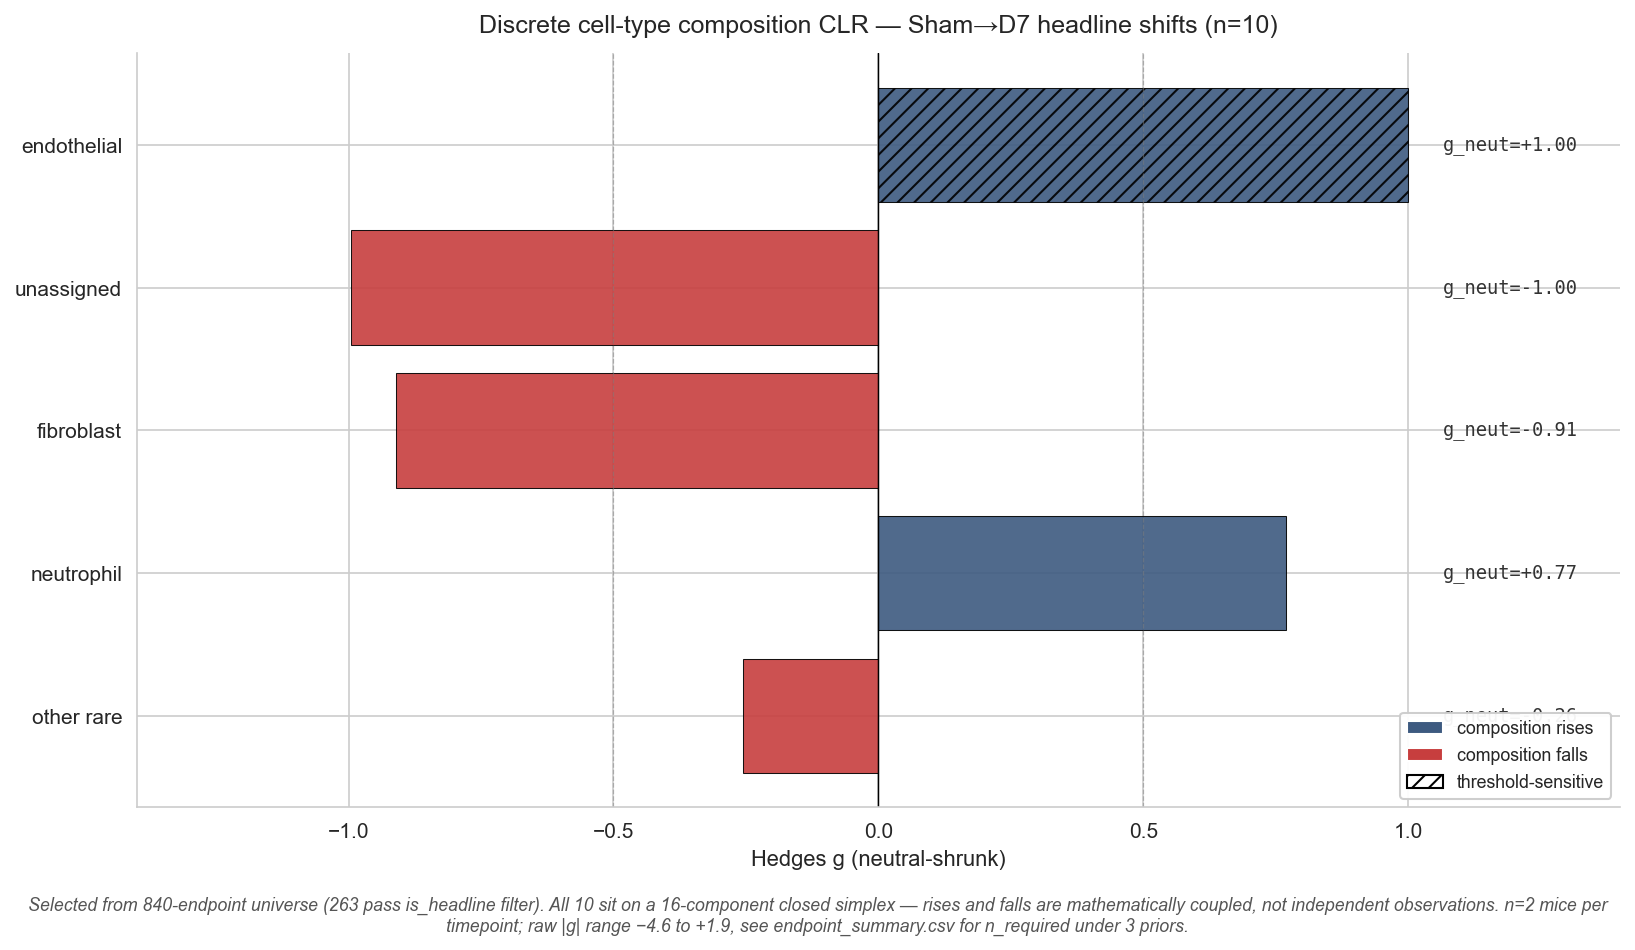

In [23]:
# Discrete cell-type CLR — Sham→D7 headline shifts (closed-simplex coordinates)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

base = project_root / 'results' / 'biological_analysis' / 'temporal_interfaces'
endpoint_df = pd.read_csv(base / 'endpoint_summary.csv')
for col in ['g_pathological', 'is_headline', 'support_sensitive', 'threshold_sensitive']:
    if col in endpoint_df.columns:
        endpoint_df[col] = (endpoint_df[col] == True)

discrete = endpoint_df[
    (endpoint_df['family'] == 'A_interface_clr') &
    (endpoint_df['endpoint_axis'] == 'discrete_celltype_16cat') &
    (endpoint_df['tp1'] == 'Sham') & (endpoint_df['tp2'] == 'D7') &
    (endpoint_df['is_headline'])
].copy()
# Largest |g| at top (matplotlib barh inverts y-axis by default)
discrete = discrete.reindex(discrete['g_shrunk_neutral'].abs().sort_values(ascending=True).index)
discrete['label'] = discrete['endpoint'].str.replace('_clr', '').str.replace('_', ' ')

# Universe / selection-burden context
n_universe = len(endpoint_df)
n_headline = int(endpoint_df['is_headline'].sum())
n_thresh_sens = int(discrete['threshold_sensitive'].sum())

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(discrete))
colors = ['#C73E3E' if g < 0 else '#3D5A80' for g in discrete['g_shrunk_neutral'].values]
hatches = ['///' if t else '' for t in discrete['threshold_sensitive'].values]
bars = ax.barh(y_pos, discrete['g_shrunk_neutral'].values, color=colors, alpha=0.9,
               edgecolor='black', linewidth=0.5, hatch=hatches)

# Single annotation per bar: g_neut at fixed-x column (rightmost edge)
ANNOT_X = 1.32
for i, (_, row) in enumerate(discrete.iterrows()):
    g_neut = row['g_shrunk_neutral']
    ax.text(ANNOT_X, i, f'g_neut={g_neut:+.2f}', va='center', ha='right',
            fontsize=9, color='#333', family='monospace')

ax.axvline(0, color='black', linewidth=0.7)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
ax.axvline(-0.5, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(discrete['label'], fontsize=10)
ax.set_xlabel('Hedges g (neutral-shrunk)', fontsize=10.5)
ax.set_title('Discrete cell-type composition CLR — Sham→D7 headline shifts (n=10)',
             fontsize=12, pad=10)
ax.set_xlim(-1.4, 1.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend for hatching if any
if n_thresh_sens > 0:
    handles = [
        mpatches.Patch(facecolor='#3D5A80', label='composition rises'),
        mpatches.Patch(facecolor='#C73E3E', label='composition falls'),
        mpatches.Patch(facecolor='white', edgecolor='black', hatch='///',
                       label='threshold-sensitive'),
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=8.5, framealpha=0.95)

# Footer note: selection burden, CLR coupling, sample size
footer = (
    f'Selected from {n_universe:,}-endpoint universe ({n_headline} pass is_headline filter). '
    f'All 10 sit on a 16-component closed simplex — rises and falls are mathematically coupled, '
    f'not independent observations. n=2 mice per timepoint; raw |g| range −4.6 to +1.9, '
    f'see endpoint_summary.csv for n_required under 3 priors.'
)
fig.text(0.5, -0.04, footer, ha='center', fontsize=8.5, style='italic',
         color='#555', wrap=True)

plt.tight_layout()
plt.show()


/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8314 (\N{SUPERSCRIPT PLUS SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


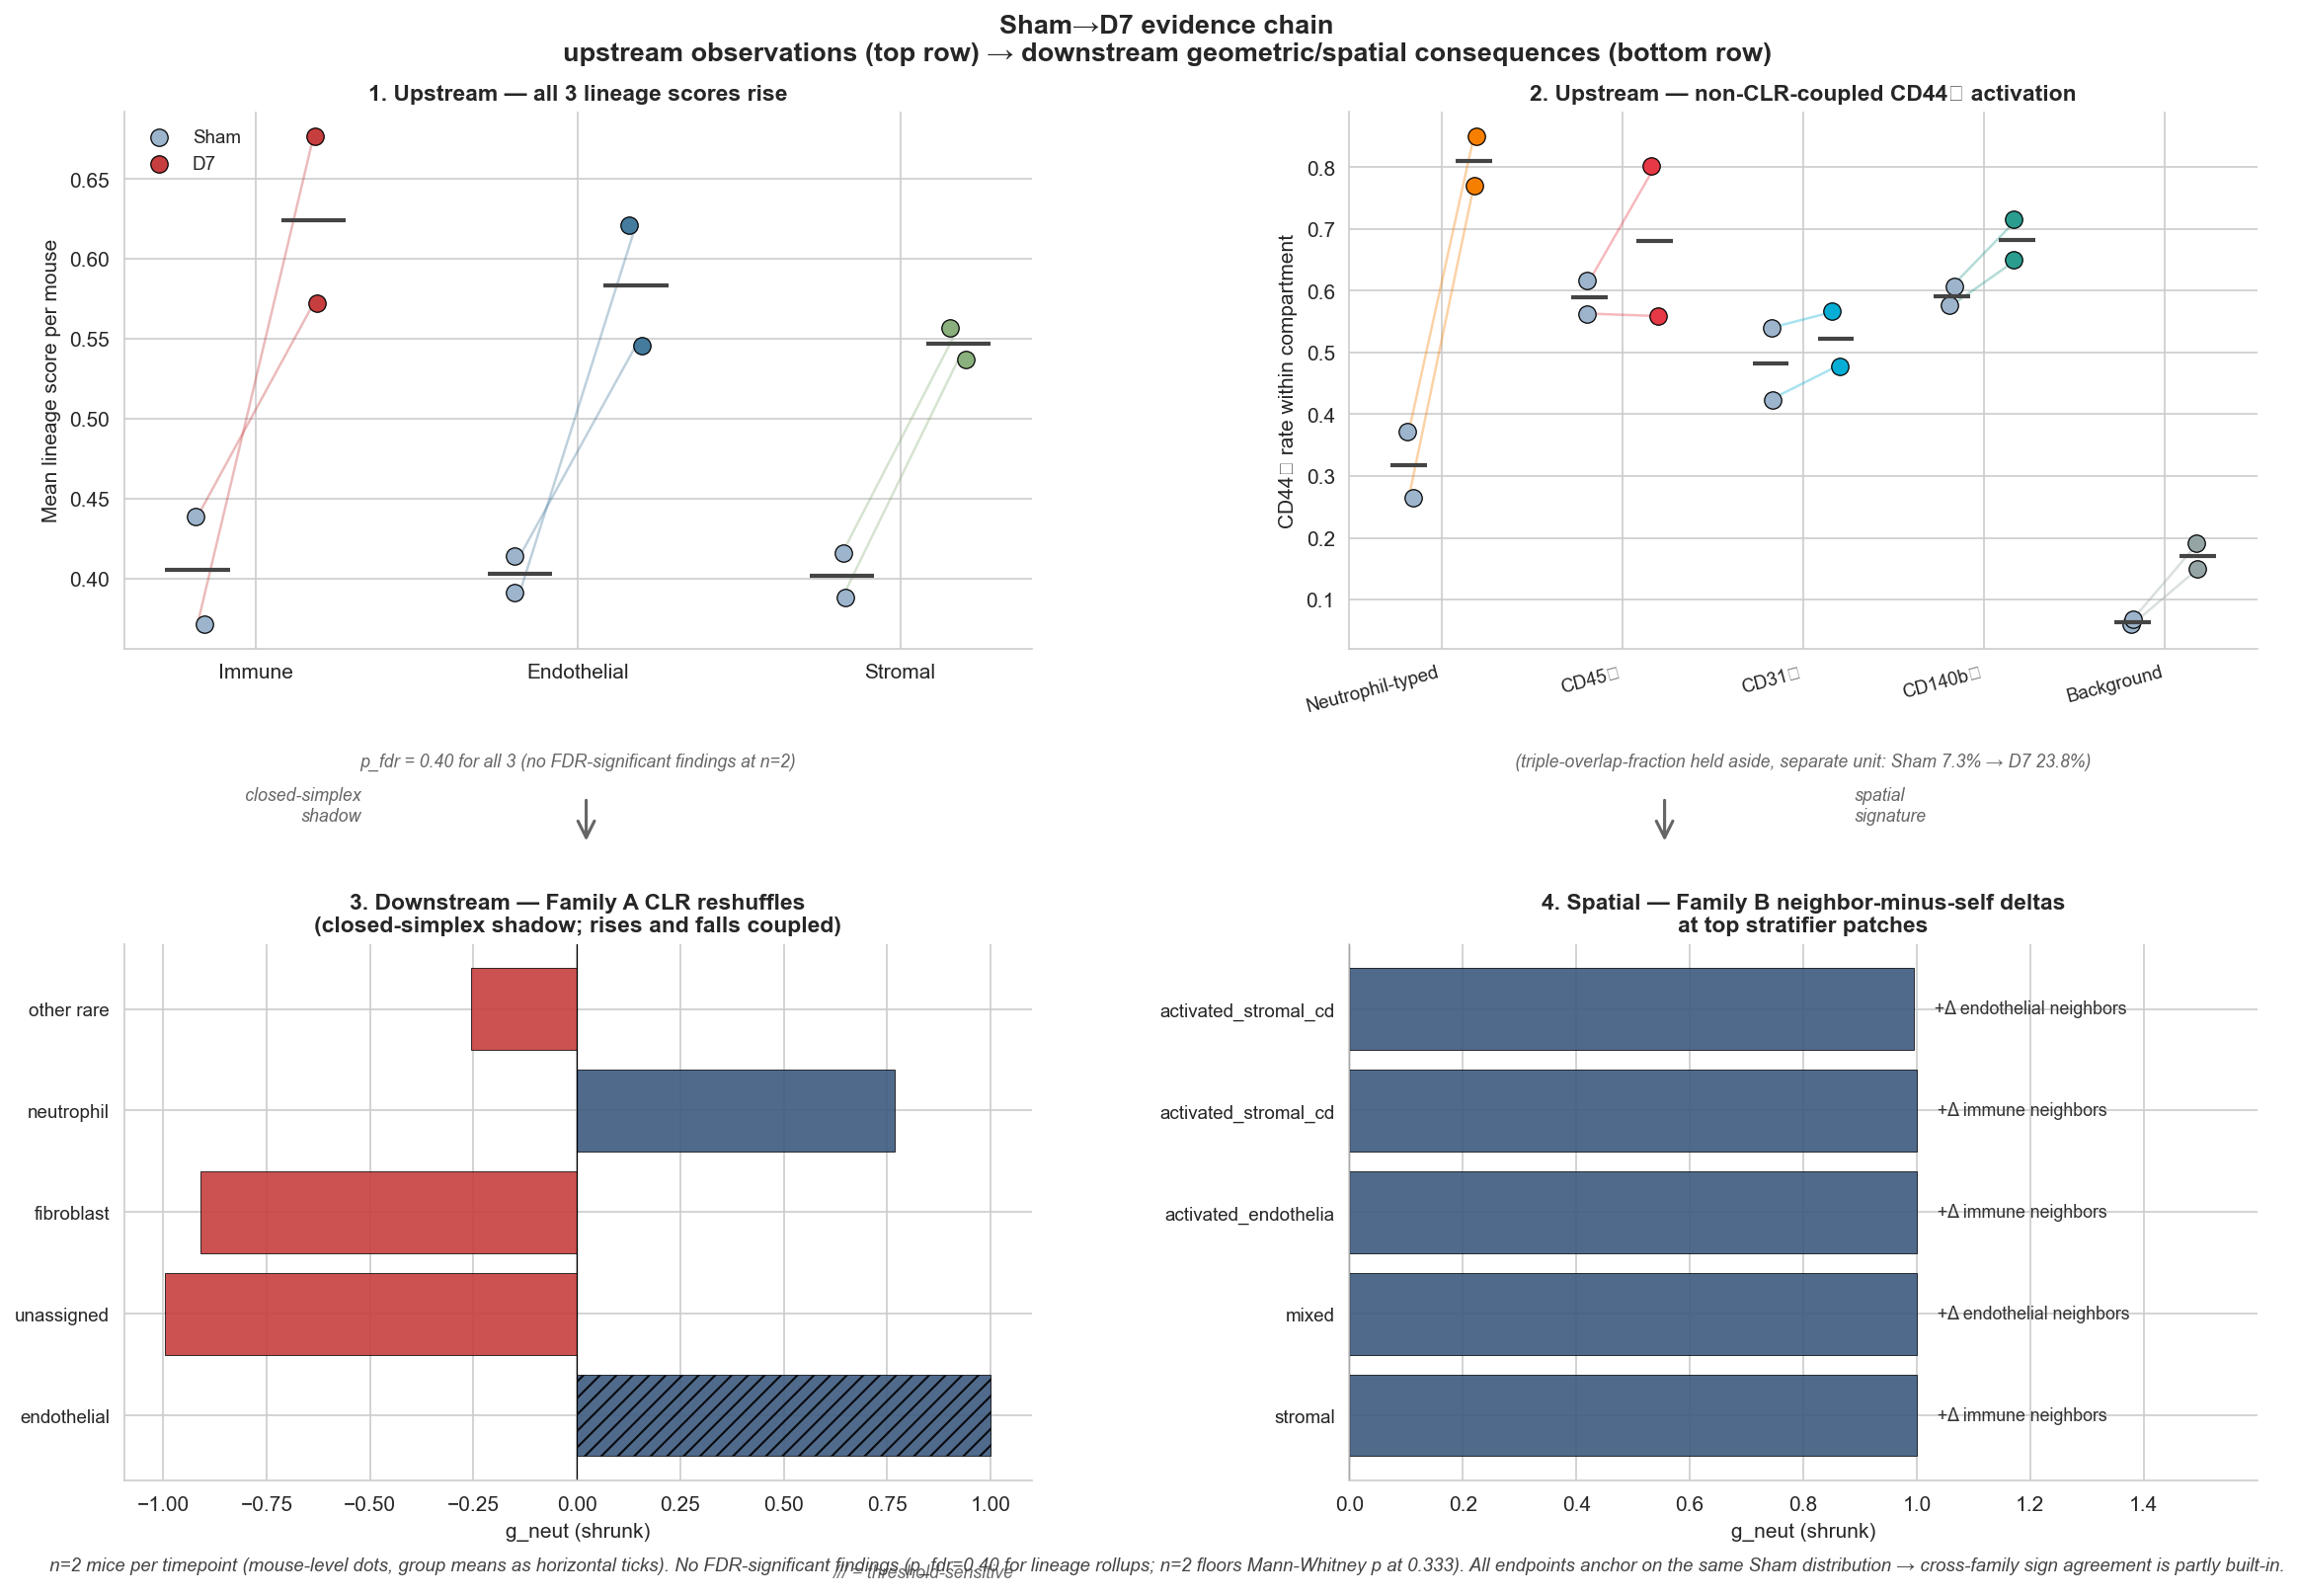

In [24]:
# The chain (Sham→D7): mouse-level dots + diverging bars across the 4 evidence surfaces
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import numpy as np

base = project_root / 'results' / 'biological_analysis' / 'temporal_interfaces'
da_dir = project_root / 'results' / 'biological_analysis' / 'differential_abundance'

endpoint_df = pd.read_csv(base / 'endpoint_summary.csv')
for col in ['is_headline', 'threshold_sensitive']:
    if col in endpoint_df.columns:
        endpoint_df[col] = (endpoint_df[col] == True)

# --- Panel 1 data: per-mouse lineage scores (Sham vs D7) ---
roi_abund = pd.read_csv(da_dir / 'roi_abundances.csv')
mouse_lin = (roi_abund.groupby(['timepoint', 'mouse'])
             [['lineage_immune_mean', 'lineage_endothelial_mean', 'lineage_stromal_mean']]
             .mean().reset_index())
lineages = ['lineage_immune_mean', 'lineage_endothelial_mean', 'lineage_stromal_mean']
lin_labels = ['Immune', 'Endothelial', 'Stromal']

rollups = pd.read_csv(da_dir / 'temporal_lineage_rollups.csv')
rollup_d7 = rollups[(rollups['cell_type'].str.startswith('lineage:')) &
                    (rollups['comparison'] == 'Sham_vs_D7')].set_index('cell_type')
p_fdr_uniform = float(rollup_d7['p_value_fdr'].iloc[0])  # all three are 0.4

# --- Panel 2 data: per-mouse compartment CD44+ rates ---
activation = pd.read_parquet(base / 'compartment_activation_temporal.parquet')
fc_compartments = [
    ('neutrophil_compartment_cd44_rate', 'Neutrophil-typed', '#F77F00'),
    ('CD45_compartment_cd44_rate', 'CD45⁺', '#E63946'),
    ('CD31_compartment_cd44_rate', 'CD31⁺', '#06AED5'),
    ('CD140b_compartment_cd44_rate', 'CD140b⁺', '#2A9D8F'),
    ('background_compartment_cd44_rate', 'Background', '#95A5A6'),
]
# triple_overlap_fraction held aside (unit mismatch — fraction of tissue, not CD44+ rate)
sham_triple = activation[activation['timepoint']=='Sham']['triple_overlap_fraction'].mean()
d7_triple = activation[activation['timepoint']=='D7']['triple_overlap_fraction'].mean()

# --- Panel 3 data: Family A discrete CT CLR (top 8 by |g|) ---
fa_ct = endpoint_df[
    (endpoint_df['family'] == 'A_interface_clr') &
    (endpoint_df['endpoint_axis'] == 'discrete_celltype_16cat') &
    (endpoint_df['tp1'] == 'Sham') & (endpoint_df['tp2'] == 'D7') &
    (endpoint_df['is_headline'])
].copy()
fa_ct = fa_ct.reindex(fa_ct['g_shrunk_neutral'].abs().sort_values(ascending=True).index).tail(8)
fa_ct['label'] = fa_ct['endpoint'].str.replace('_clr', '').str.replace('_', ' ')

# --- Panel 4 data: Family B top 5 spatial deltas, clean stratifier-on-y labels ---
fb = endpoint_df[
    (endpoint_df['family'] == 'B_continuous_neighborhood') &
    (endpoint_df['tp1'] == 'Sham') & (endpoint_df['tp2'] == 'D7') &
    (endpoint_df['is_headline'])
].copy()
fb['stratifier'] = fb['composite_label'].fillna(fb['cell_type']).fillna('?').str.replace('c:', '').str[:20]
fb['lineage_short'] = fb['endpoint'].str.replace('vs_sham_mean_delta_lineage_', '')
fb = fb.reindex(fb['g_shrunk_neutral'].abs().sort_values(ascending=True).index).tail(5)

# === Build the figure ===
fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.35,
                       left=0.06, right=0.96, top=0.91, bottom=0.07)

def dumbbell(ax, panel_data, x_labels, colors, ylabel, title, footer=None):
    """Mouse-level dot-dumbbell plot. panel_data: list of {sham: [..], d7: [..]}."""
    n = len(panel_data)
    x_pos = np.arange(n)
    sham_x = -0.18
    d7_x = +0.18
    rng = np.random.RandomState(42)

    for i, (entry, color) in enumerate(zip(panel_data, colors)):
        sham_vals = entry['sham']
        d7_vals = entry['d7']
        # paired connecting lines — pair by mouse index
        n_pairs = min(len(sham_vals), len(d7_vals))
        for j in range(n_pairs):
            ax.plot([i + sham_x, i + d7_x], [sham_vals[j], d7_vals[j]],
                    color=color, alpha=0.35, linewidth=1.2, zorder=2)
        # mouse dots with tiny jitter
        sjit = rng.uniform(-0.025, 0.025, len(sham_vals))
        djit = rng.uniform(-0.025, 0.025, len(d7_vals))
        ax.scatter(np.full(len(sham_vals), i + sham_x) + sjit, sham_vals,
                   color='#9CB4CC', edgecolor='black', linewidth=0.6, s=70, zorder=3,
                   label='Sham' if i == 0 else None)
        ax.scatter(np.full(len(d7_vals), i + d7_x) + djit, d7_vals,
                   color=color, edgecolor='black', linewidth=0.6, s=70, zorder=3,
                   label='D7' if i == 0 else None)
        # group means as horizontal ticks
        ax.hlines(np.mean(sham_vals), i + sham_x - 0.1, i + sham_x + 0.1,
                  color='#444', linewidth=2, zorder=4)
        ax.hlines(np.mean(d7_vals), i + d7_x - 0.1, i + d7_x + 0.1,
                  color='#444', linewidth=2, zorder=4)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if footer:
        ax.text(0.5, -0.22, footer, transform=ax.transAxes, ha='center',
                fontsize=8.5, style='italic', color='#666')


# --- Panel 1: Layer B lineage scores ---
ax1 = fig.add_subplot(gs[0, 0])
panel_data = []
for col in lineages:
    sham_vals = mouse_lin[mouse_lin['timepoint']=='Sham'][col].values
    d7_vals = mouse_lin[mouse_lin['timepoint']=='D7'][col].values
    panel_data.append({'sham': sham_vals, 'd7': d7_vals})
dumbbell(ax1, panel_data, lin_labels,
         colors=['#C73E3E', '#457B9D', '#8AB17D'],
         ylabel='Mean lineage score per mouse',
         title='1. Upstream — all 3 lineage scores rise',
         footer=f'p_fdr = {p_fdr_uniform:.2f} for all 3 (no FDR-significant findings at n=2)')
ax1.legend(loc='upper left', fontsize=9, frameon=False)

# --- Panel 2: Family C compartment CD44+ rates ---
ax2 = fig.add_subplot(gs[0, 1])
panel_data = []
labels2 = []
colors2 = []
for col, label, color in fc_compartments:
    sham_vals = activation[activation['timepoint']=='Sham'][col].dropna().values
    d7_vals = activation[activation['timepoint']=='D7'][col].dropna().values
    panel_data.append({'sham': sham_vals, 'd7': d7_vals})
    labels2.append(label)
    colors2.append(color)
dumbbell(ax2, panel_data, labels2, colors2,
         ylabel='CD44⁺ rate within compartment',
         title='2. Upstream — non-CLR-coupled CD44⁺ activation',
         footer=f'(triple-overlap-fraction held aside, separate unit: '
                f'Sham {sham_triple:.1%} → D7 {d7_triple:.1%})')
ax2.tick_params(axis='x', rotation=15)
for tick in ax2.get_xticklabels():
    tick.set_horizontalalignment('right')
    tick.set_fontsize(9)

# --- Panel 3: Family A discrete CT CLR (closed-simplex consequence) ---
ax3 = fig.add_subplot(gs[1, 0])
y = np.arange(len(fa_ct))
colors3 = ['#C73E3E' if g < 0 else '#3D5A80' for g in fa_ct['g_shrunk_neutral'].values]
hatches3 = ['///' if t else '' for t in fa_ct['threshold_sensitive'].values]
ax3.barh(y, fa_ct['g_shrunk_neutral'].values, color=colors3, alpha=0.9,
         edgecolor='black', linewidth=0.4, hatch=hatches3)
ax3.set_yticks(y)
ax3.set_yticklabels(fa_ct['label'].values, fontsize=9)
ax3.invert_yaxis()
ax3.axvline(0, color='black', linewidth=0.6)
ax3.set_xlabel('g_neut (shrunk)')
ax3.set_title('3. Downstream — Family A CLR reshuffles\n(closed-simplex shadow; rises and falls coupled)',
              fontsize=11, fontweight='bold')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
if any(hatches3):
    ax3.text(0.98, -0.18, '/// = threshold-sensitive', transform=ax3.transAxes,
             ha='right', fontsize=8.5, style='italic', color='#666')

# --- Panel 4: Family B spatial concentration ---
ax4 = fig.add_subplot(gs[1, 1])
y = np.arange(len(fb))
colors4 = ['#C73E3E' if g < 0 else '#3D5A80' for g in fb['g_shrunk_neutral'].values]
ax4.barh(y, fb['g_shrunk_neutral'].values, color=colors4, alpha=0.9,
         edgecolor='black', linewidth=0.4)
ax4.set_yticks(y)
ax4.set_yticklabels(fb['stratifier'].values, fontsize=9)
ax4.invert_yaxis()
ax4.axvline(0, color='black', linewidth=0.6)
ax4.set_xlabel('g_neut (shrunk)')
# Annotate each bar with the lineage being acquired/lost
for i, (_, row) in enumerate(fb.iterrows()):
    sign = '+' if row['g_shrunk_neutral'] > 0 else '−'
    annot = f'  {sign}Δ {row["lineage_short"]} neighbors'
    x = row['g_shrunk_neutral']
    side = 'left' if x > 0 else 'right'
    offset = 0.02 if x > 0 else -0.02
    ax4.text(x + offset, i, annot, va='center', ha=side, fontsize=8.5, color='#333')
ax4.set_title('4. Spatial — Family B neighbor-minus-self deltas\nat top stratifier patches',
              fontsize=11, fontweight='bold')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
_xl, _xr = ax4.get_xlim(); ax4.set_xlim(_xl * 1.05, _xr + 0.55)  # extra room for bar-end annotations

# --- Vertical flow arrows between top and bottom panels ---
arrow_kwargs = dict(arrowstyle='->', mutation_scale=20, color='#666',
                    linewidth=1.5, transform=fig.transFigure)
arrow_left = FancyArrowPatch((0.255, 0.49), (0.255, 0.46), **arrow_kwargs)
arrow_right = FancyArrowPatch((0.71, 0.49), (0.71, 0.46), **arrow_kwargs)
fig.add_artist(arrow_left)
fig.add_artist(arrow_right)
fig.text(0.16, 0.475, 'closed-simplex\nshadow', fontsize=8.5, style='italic',
         color='#666', ha='right')
fig.text(0.79, 0.475, 'spatial\nsignature', fontsize=8.5, style='italic',
         color='#666', ha='left')

# --- Suptitle (2 clean lines) ---
fig.suptitle('Sham→D7 evidence chain\nupstream observations (top row) → downstream geometric/spatial consequences (bottom row)',
             fontsize=13, fontweight='bold', y=0.97)

# --- Footer: critical caveats ---
footer = ('n=2 mice per timepoint (mouse-level dots, group means as horizontal ticks). '
          'No FDR-significant findings (p_fdr=0.40 for lineage rollups; n=2 floors Mann-Whitney p at 0.333). '
          'All endpoints anchor on the same Sham distribution → cross-family sign agreement is partly built-in.')
fig.text(0.5, 0.015, footer, ha='center', fontsize=9, style='italic', color='#444', wrap=True)

plt.show()


### Reading the candidate finding

#### Executive summary

In mouse kidney 7 days after UUO injury, CD44⁺ activation rate within Ly6G-gated tissue (10 µm superpixels) rises from 32% to 81% — the largest single-compartment effect in this 9-marker IMC pilot and the most cell-type-specific non-tautological CD44 rate the panel computes. CD44⁺ also rises in the background (no compartment marker) and CD140b⁺ compartments, alongside a rise in the CD45⁺/CD31⁺/CD140b⁺ triple-overlap *fraction* (a co-occurrence statistic, not itself a CD44 rate). The continuous immune, endothelial, and stromal lineage scores all rise simultaneously Sham→D7. Compositional CLR shows multi-lineage interface fractions growing relative to single-lineage fractions, but at n=2 mice/timepoint these shifts cannot be distinguished from the closed-simplex projection of the broader activation. n_required under a neutral Bayesian prior is 16, 17, 18, 38 for the four Family C headlines (the CD140b⁺ compartment at n=38 is the high outlier); 16, 17, 20, 27, 28, 29, 30, 41, 51 for the discrete-cell-type CLR signatures named below (plus a smallest-effect endpoint at n=230, addressed in §7); n=20 mice per timepoint clears three of four Family C headlines and most CLR signatures with margin under the neutral prior.


#### How the four surfaces support that summary

The headline tables sit on top of two upstream observations the analysis already surfaced:

1. **Every continuous lineage score rises Sham→D7** (§3D rollups). Stromal, endothelial, and immune all shift in the same direction. Underlying p_fdr = 0.40 (no FDR-significant findings at n=2/timepoint).
2. **CD44⁺ activation rates rise within four Family C compartments** (next cell). Largest in the cohort: Ly6G-gated tissue 32% → 81%; triple-overlap fraction (a co-occurrence statistic, distinct from CD44 rate) triples; background tissue acquires CD44⁺ at ~2.7×; CD140b⁺ compartment rises modestly.

These two are non-CLR-coupled (Family C compartments are independent denominators; the §3D rollups are simple means of continuous scores). The Family A compositional shifts in the headline tables sit downstream of (1) on a closed simplex — when multiple lineage scores rise together, the relative composition must reshuffle. The discrete cell-type CLR adds finer-grained texture about *which* activated subtypes acquire mass on the simplex. Family B locates the spatial signature of where the activation concentrates.

#### How each family reads against this chain

- **Family A — lineage-interface CLR (closed simplex of 8 categories).** Triple-positive interface (`endothelial+immune+stromal`) rises (g_neut ≈ +0.99); pairwise overlaps rise (each g_neut ≈ +0.5); pure `immune` falls (g_neut ≈ −0.39). The dual-normalization filter dropped four endpoints (`stromal_clr`, `endothelial_clr`, `none_clr`, `endothelial+stromal_clr`) where the direction or magnitude depended on which normalization path was used, which is itself evidence that the simplex coordinates are partly geometric. *On its own, this surface cannot distinguish "per-cell-type redistribution" from "broad lineage rises projected through a closed simplex."*
- **Family A — discrete cell-type CLR (16 categories, post-remediation min-prevalence collapse to 5 active typed coords + `other_rare` + `unassigned`).** Adds finer-grained texture: bare `endothelial` (+1.00) and `neutrophil` (+0.77) rise; `unassigned` (−1.00), `fibroblast` (−0.91), and `other_rare` (−0.26) fall; `immune_cells` (−1.00) is demoted under the v1/v2 cross-rule because the v1 lineage analog already headlines. The activated_*_cd44 / activated_*_cd140b subtypes are absorbed into `other_rare` under the post-remediation simplex because their per-mouse prevalence falls below 1%. The shifts identify *which* discrete subtypes the broad activation lands on in the cell-type vocabulary.
- **Family B — neighbor-minus-self lineage delta (graph-topological).** 51 raw is_headline rows at Sham→D7 (counting both sigmoid and raw arcsinh basis surfaces), of which 14 clear in the conservative both-bases intersection (kidney notebook Part 2.5 reports the breakdown). Top rows are dominated by `vs_sham_mean_delta_lineage_immune` and `..._endothelial` deltas around stromal- and activated-endothelial-labeled superpixels. The neighbor-minus-self operation is differential, so the Sham-reference offset cancels and the raw arcsinh basis is genuinely sigmoid-independent. Locates where the activation concentrates spatially: at the boundaries between lineage-distinct patches.
- **Family C — Sham-referenced compartment activation (per-compartment rate, non-CLR-coupled).** `neutrophil_compartment_cd44_rate` rises from 31.8% → 81.1% (g_neut ≈ +1.00); `triple_overlap_fraction` 7.3% → 23.8% (g_neut ≈ +0.98 — note this is a co-occurrence fraction, not a CD44 rate); `background_compartment_cd44_rate` 6.4% → 17.0% (g_neut ≈ +0.95); `CD140b_compartment_cd44_rate` 59.2% → 68.3% (g_neut ≈ +0.64). CD45⁺ and CD31⁺ compartments rise too but do not clear the headline filter; they are directional, not headline-grade.

#### Candidate signatures (UUO-relevant, hypothesis-generating)

The discrete cell-type CLR shifts above are gate-derived superpixel categories on a 16-component closed simplex; their movements are mathematically coupled. Four candidate patterns warrant follow-up. We are explicit about which observations escape the simplex and which are mechanically forced by it. **None is a confirmed mechanism**; each is a discriminator for a powered follow-up with αSMA, collagen, proliferation markers, and lineage tracing — none of which this 9-marker panel includes.

- **PDGFRβ co-occurrence shifts toward the CD45⁺ compartment.** `activated_m2_cd140b_clr` rises (g_neut ≈ +0.74) while `activated_fibroblast_cd140b_clr` falls (g_neut ≈ −1.00). At 10 µm superpixel resolution this is *PDGFRβ co-binning more with CD45⁺CD11b⁺CD206⁺ tissue and less with CD140a⁺ stromal tissue*. Three competing readings, not distinguishable in this cohort:
   - *Macrophage-mesenchymal transition (MMT)* — bone-marrow-derived macrophages acquire mesenchymal markers including αSMA via TGF-β/Smad3 signaling (Wang et al. 2016, *Oncotarget*; the cited paper demonstrates αSMA acquisition rather than PDGFRβ specifically — the panel here would test the broader MMT framing rather than a specific marker mechanism).
   - *Pericyte mobilization* — pericytes (CD140b⁺) migrate toward CD45⁺ niches; the canonical pericyte→myofibroblast transition (Lin et al. 2008, Humphreys et al. 2010) requires αSMA acquisition and places myofibroblasts in the CD45⁻ compartment, which this panel cannot test.
   - *Spatial co-binning* — PDGFRβ⁺ pericytes adjacent to invading CD45⁺ macrophages get aggregated into the same 10 µm superpixel.

   A follow-up panel with αSMA, collagen-1, and macrophage/pericyte lineage tracers discriminates.

- **CD44 redistribution within CD140a⁺ stromal tissue.** `fibroblast_clr` falls (g_neut ≈ −0.89) while `activated_fibroblast_cd44_clr` rises (g_neut ≈ +0.56). On the closed simplex this is mechanically forced by the global CD44 rise restricted to the PDGFRα⁺ subset — it is the same observation as Family C's CD140b⁺-compartment CD44⁺ rise (g_neut ≈ +0.64) viewed through the discrete-cell-type vocabulary. Whether the redistribution reflects fibroblast activation, recruitment, or proliferation is not measurable in this panel (no Ki67, EdU, PCNA, αSMA, or collagen).

- **Ly6G⁺ compartment acquires a CD44⁺ signature without proportional Ly6G expansion.** Mean Ly6G expression is flat across timepoints (Part 5 / §4 spatial enrichment), the discrete `neutrophil_clr` rises modestly (g_neut ≈ +0.62), and the CD44⁺ rate within Ly6G⁺ tissue jumps from 32% → 81% (Family C, g_neut ≈ +1.00 — the largest defensible effect in the cohort). The data does not identify the direction of the arrow:
   - *Neutrophils acquire CD44* (activation in place).
   - *Non-neutrophil CD44⁺ cells* (macrophages, fibroblasts, lymphocytes) infiltrate Ly6G⁺ tubulointerstitial niches at superpixel resolution. UUO models commonly show macrophage takeover by D7 (Ryu et al. 2022 reports Siglec-F⁺ neutrophils in renal fibrosis but Siglec-F is not in this panel).

   Both readings produce the same Family C statistic. Sub-cellular resolution or lineage tracing is required to discriminate.

- **Largest |g| effect: CD44⁺ activation moves *off* the activated-myeloid compartment.** `activated_myeloid_cd44_clr` falls (g_neut ≈ −0.99, raw |g|=4.63 — the largest discrete-cell-type CLR shift in the dataset). On the closed simplex this is mechanically forced when CD44⁺ rate rises elsewhere — but the *direction* (myeloid losing CD44 mass while fibroblast and m2 gain it) is the closed-simplex texture of the broad-activation reading: **CD44⁺ tissue increasingly co-occurs with PDGFRα⁺ stromal markers and CD45⁺CD11b⁺CD206⁺ M2 markers, less with bare CD11b⁺ myeloid markers.** Per Family C, CD45⁺-compartment CD44⁺ rate rises only modestly (not headline-grade), corroborating the same picture. This is consistent with M2 macrophage expansion + activated-fibroblast emergence at the expense of bare-myeloid tissue, a documented UUO time course.

- **Asymmetric endothelial CD44 trajectory — the one signal that escapes the global rise.** Within CD31⁺CD34⁺ endothelial tissue, `endothelial_clr` rises (g_neut ≈ +0.77, **threshold-sensitive — hatched in the bar chart above**) while `activated_endothelial_cd44_clr` falls (g_neut ≈ −0.74). This is the only headline endpoint pair where CD44 *falls* within a lineage compartment while it rises everywhere else (Family C). The closed simplex would predict the global direction within each subset, not the opposite — so this asymmetry would be genuinely interesting *if* it were threshold-stable. It is not: `endothelial_clr` is flagged `threshold_sensitive=True` (hatched in the bar chart above), meaning the 16-category CLR partition reassigns this endpoint across the {65, 75, 85} percentile sweep. Until the threshold sensitivity is resolved, treat the asymmetry as method-dependent rather than a clean biological exception. Possible readings (none testable in this panel): the appearance of bare-endothelial structures (new vessels) without CD44, selective CD44 loss within mature endothelium, or the threshold-sensitivity flag indicating the endothelial-CLR partition is method-dependent. Vascular biology this would invoke (rarefaction, angiogenesis, endothelial-to-mesenchymal transition — reviewed across the pericyte/EndMT literature) requires vascular density, αSMA, and EndMT lineage markers not in the panel.

These four patterns are biologically coherent for a UUO time course at D7. The first three are simplex- or co-binning-coupled; only the endothelial asymmetry escapes that coupling. None is mechanistically confirmed at n=2.


#### What the cohort can and cannot distinguish

The chain above frames the headline tables as nested observations that fit together: broad lineage-score rises and broad CD44⁺ activation upstream; closed-simplex CLR reshuffle and per-cell-type subtype texture downstream; spatial concentration at compartment boundaries (Family B) as the geometric signature.

What this cohort *cannot* distinguish at n=2:
- **(a)** per-cell-type biological redistribution where specific populations move between categories, with broad activation as a secondary marker, vs.
- **(b)** broad multi-lineage activation that hits every compartment, with the apparent compositional redistribution being the closed-simplex projection of that activation.

Both readings are consistent with the data. The Family C non-CLR rises and the §3D all-lineages-rise observation make (b) the more parsimonious read, but (a) cannot be excluded — distinguishing them requires lineage tracing or longitudinal sampling, neither of which this cohort has. The shared n=2 Sham anchor across all families means sign agreement between them is partly built-in regardless. The factor-of-10 spread between skeptical and optimistic Bayesian priors is the honest uncertainty bound.

**Cross-rule note.** A discrete cell-type endpoint that maps to the same biological compartment as a passing lineage-interface endpoint (e.g., `endothelial_clr` discrete vs `endothelial` lineage) is demoted via `headline_demoted_reason='cross_axis_co_headline_forbidden'` so the same event isn't double-counted as "two converging signals." The audit count printed above quantifies how many rows the rule fires on — it is structural, applying only where the two vocabularies overlap.


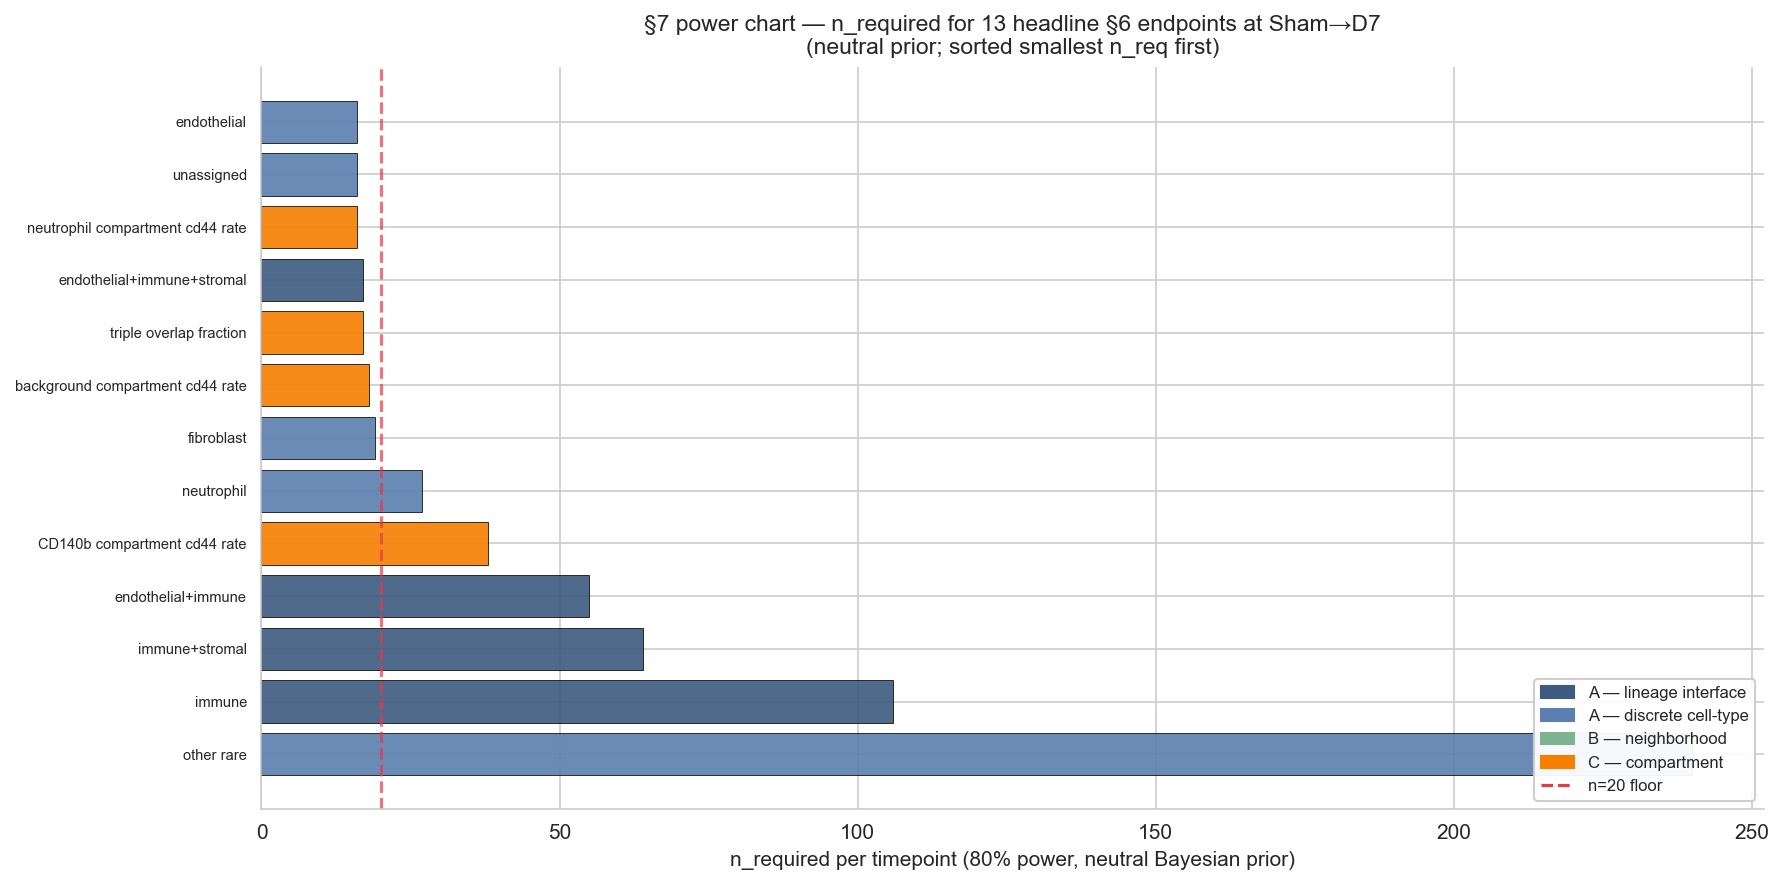

Per-family n_required summary (neutral prior):
             fam_label  n_endpoints  n_req_min  n_req_max  n_req_median
A — discrete cell-type            5       16.0      240.0          19.0
 A — lineage interface            4       17.0      106.0          59.5
       C — compartment            4       16.0       38.0          17.5


In [25]:
# --- 6b. Power chart anchored in §6 headline endpoints ---
# Reads endpoint_summary.csv directly and renders n_required under the neutral
# Bayesian prior for every is_headline=True row at Sham→D7. This is the chart
# §7's recommendations are anchored in. Color-coded by family + endpoint axis.
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

base = project_root / 'results' / 'biological_analysis' / 'temporal_interfaces'
endpoint_pwr = pd.read_csv(base / 'endpoint_summary.csv')
for col in ['is_headline', 'g_pathological']:
    if col in endpoint_pwr.columns:
        endpoint_pwr[col] = (endpoint_pwr[col] == True)

sham_d7 = endpoint_pwr[(endpoint_pwr['tp1']=='Sham') & (endpoint_pwr['tp2']=='D7')
                      & endpoint_pwr['is_headline']
                      & (endpoint_pwr['family'] != 'B_continuous_neighborhood')].copy()
# Family + axis grouping for color
def fam_label(row):
    fam = row['family']
    if fam == 'A_interface_clr':
        return 'A — lineage interface' if row.get('endpoint_axis') == 'composite_label_8cat' else 'A — discrete cell-type'
    if fam == 'B_continuous_neighborhood':
        return 'B — neighborhood'
    if fam == 'C_compartment_activation':
        return 'C — compartment'
    return fam

sham_d7['fam_label'] = sham_d7.apply(fam_label, axis=1)
fam_colors = {
    'A — lineage interface': '#3D5A80',
    'A — discrete cell-type': '#5B7FB0',
    'B — neighborhood': '#7DB48F',
    'C — compartment': '#F77F00',
}

# Sort: ascending n_req (smallest n_req at top — the most defensible to power around)
sham_d7 = sham_d7.sort_values('n_required_neutral', ascending=True)

# Truncate endpoint label for readability
sham_d7['display'] = sham_d7['endpoint'].str.replace('_clr', '').str.replace('_', ' ').str[:42]

fig, ax = plt.subplots(figsize=(12, max(6, 0.18 * len(sham_d7))))
y_pos = np.arange(len(sham_d7))
bar_colors = [fam_colors[f] for f in sham_d7['fam_label']]
ax.barh(y_pos, sham_d7['n_required_neutral'].values, color=bar_colors,
        edgecolor='black', linewidth=0.4, alpha=0.9)

ax.axvline(20, color='#E63946', linestyle='--', linewidth=1.5, alpha=0.7,
           label='Recommended floor (n=20)')
ax.set_yticks(y_pos)
ax.set_yticklabels(sham_d7['display'], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('n_required per timepoint (80% power, neutral Bayesian prior)', fontsize=10)
ax.set_title(f'§7 power chart — n_required for {len(sham_d7)} headline §6 endpoints at Sham→D7\n'
             '(neutral prior; sorted smallest n_req first)',
             fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

handles = [mpatches.Patch(color=c, label=l) for l, c in fam_colors.items()]
handles.append(plt.Line2D([0], [0], color='#E63946', linestyle='--', label='n=20 floor'))
ax.legend(handles=handles, loc='lower right', fontsize=8, framealpha=0.95)
plt.tight_layout()
plt.show()

# Print compact summary by family
fam_summary = sham_d7.groupby('fam_label').agg(
    n_endpoints=('endpoint', 'count'),
    n_req_min=('n_required_neutral', 'min'),
    n_req_max=('n_required_neutral', 'max'),
    n_req_median=('n_required_neutral', 'median'),
).reset_index()
print('Per-family n_required summary (neutral prior):')
print(fam_summary.to_string(index=False))


## 7. Follow-Up Study Design

### Sample-size budget: anchored in the §7 power chart

The chart above renders `n_required` per headline §6 endpoint under the **neutral Bayesian prior** N(0, 1²) — the planning default. Reading the per-family summary printed below the chart:

- **Family C compartment activation** (the non-CLR-coupled, most defensible surface): n_req = 16, 17, 18, 38 across the 4 headlines. The first three (neutrophil-typed CD44⁺ rate, triple-overlap fraction, background CD44⁺ rate) clear at n=20 with margin; CD140b⁺-compartment CD44⁺ rate at n_req=38 needs n=40.
- **Family A lineage-interface CLR**: n_req = 17, 55, 64, 106 across the 4 headlines. Only the triple-positive interface (n=17) clears at n=20; the three pairwise/single-lineage shifts need n≥55.
- **Family A discrete cell-type CLR**: n_req = 16, 17, 20, 27, 28, 29, 30, 41, 51 across the 9 substantive headlines (one additional headline `activated_m2_cd44_clr` has n_req=230 — see below). At n=20, four of nine clear; the rest need n≥27.
- **Family B continuous neighborhood**: 51 raw headlines, 14 in the conservative both-bases intersection. n_req varies widely; treat as ranked exploration.

**Recommendation: n=20 mice per timepoint (80 mice total).** This clears 3 of 4 Family C headlines plus the triple-positive interface CLR plus the four largest discrete-cell-type CLR effects with margin. CD140b⁺-compartment CD44⁺ rate (n_req=38) and the moderate CLR endpoints (n_req 27–51) are partially powered. For full coverage of every named candidate signature, n=51 per timepoint would suffice.

**`activated_m2_cd44_clr` (n_req=230) is honest disclosure.** The endpoint passes every is_headline gate (`|g|>0.5`, support, pathology, cross-rule) but its observed effect (g_neut=+0.26) is much smaller than the others, so the required-n is much larger. We list it for transparency rather than dismiss it; n=20 does not power it, and a powered follow-up should not power around this specific endpoint as a primary target.

**Skeptical-prior bracket.** For a pivotal confirmatory study against the skeptical prior N(0, 0.5²), the headline n_req values are 158–690 across the named-signature subset (median ~210). The activated_m2_cd44_clr long-tail outlier reaches n_req=1468 under skeptical. A defensible skeptical-prior cohort budget is **n=160–280 per timepoint** for the largest-effect headlines; n=80 does not cover any. For a proof-of-concept replication under the optimistic prior, n=3–14 suffices but only resolves the four largest effects.

### Panel expansion: tied to the discriminator experiments

The §6 synthesis names four candidate signatures the current panel cannot disambiguate. The follow-up panel should add markers tied to each:

- **For the PDGFRβ-redistribution signal (pericyte-vs-MMT discrimination):** add αSMA (ACTA2) and collagen-1 (COL1A1). Pericyte→myofibroblast transition (Lin/Humphreys) requires PDGFRβ⁺ + αSMA⁺ on a CD45⁻ background. MMT (Wang et al. 2016) requires PDGFRβ⁺ + αSMA⁺ on a CD45⁺ background. Without αSMA, neither mechanism is testable.
- **For the CD44-redistribution-within-stroma signal (activation vs proliferation):** add Ki67 or EdU labeling. Cannot exclude proliferation without a proliferation marker.
- **For the Ly6G-compartment CD44 signature (neutrophil activation vs macrophage takeover):** add Siglec-F (Ryu et al. 2022 — Siglec-F⁺ neutrophils in renal fibrosis), and additional macrophage polarization (M1: CD86, TNF; M2: Arg1, Mrc2 beyond CD206). Distinguishes whether the Ly6G⁺ compartment is acquiring CD44 via in-place activation or via macrophage infiltration.
- **For the asymmetric endothelial CD44 trajectory (rarefaction vs angiogenesis vs EndMT):** add EndMT lineage markers (e.g., FSP1, vimentin), vascular density quantification, αSMA (also serves the pericyte question).
- **For panel coverage breadth:** tubular epithelium (E-cadherin, KIM-1, aquaporin) reduces the ~86% mean unassigned-tissue fraction under strict discrete gating (or the ~19% no-lineage fraction under continuous lineage thresholding at 0.3, depending on which annotation surface the follow-up powers around). T/B lymphocyte subsets (CD3, CD4, CD8, CD20) capture the adaptive immune compartment currently invisible.

A 20-marker panel covering these targets plus the existing 9 is a reasonable target. With 20 markers, pathway enrichment (currently precluded at n=8 groundable genes) becomes feasible.

### Normalization plan: a non-Sham-anchored second path

Every §6 endpoint anchors on the same n=2 Sham distribution × 3 ROIs, so cross-family sign agreement is partly built-in. The follow-up cohort should run a parallel non-Sham-anchored normalization path to discriminate. Two options:

- **Total-ion normalization** — divide each marker by the per-pixel ion-count sum. Removes per-ROI laser/detector variation without anchoring on any specific timepoint group.
- **Housekeeping-channel normalization** — include an injury-invariant marker (e.g., a constitutive structural protein) in the panel and normalize against it.

Either path gives an independent comparison surface that is not Sham-anchored. Cross-checking against the existing Sham-reference path quantifies how much of the candidate finding is method-dependent rather than biological.

### Acquisition design

- **Variable field-of-view** (whole-section IMC or panoramic montage). Every ROI in the current cohort is the same ~500×500 µm field, which makes area-based density a tautology with proportion — `tissue_area_mm2` has CV=0.012 across 24 ROIs. Variable extent gains real cross-ROI variance and lets density become an independent endpoint.
- **Per-nucleus density via DNA watershed segmentation.** Wire `src/analysis/watershed_segmentation.py` (currently not in production) so the denominator becomes nuclear count rather than tissue area.
- **Longitudinal sampling where feasible.** Same animals across timepoints via survival surgery enables paired analyses and separates biological variability from temporal progression. UUO is amenable to survival surgery; a longitudinal arm (n=10 mice, 4 timepoints each) costs the same animals as the cross-sectional design but yields paired comparisons.
- **Regional stratification.** Paired Wilcoxon signed-rank for cortex-vs-medulla comparisons from the same mouse (currently treated as independent observations).

### What would falsify the candidate finding

A powered follow-up with the proposed design and panel should produce one of three outcomes. The first confirms; the second and third falsify in different ways:

1. **Confirmation.** Family C neutrophil-typed CD44⁺ rate at D7 lands at ≥60% (current pilot: 81%, with n=20 and 80% power against neutral prior the lower confidence bound at the observed effect lands well above 60%). Triple-overlap fraction at least doubles. Background CD44⁺ rate at least doubles. Compositional CLR shifts in the same direction as the pilot.
2. **Falsification by null.** Family C neutrophil-typed CD44⁺ rate at D7 returns to within 10% of Sham (≤40%). Compositional CLR shifts are not direction-consistent with the pilot. The candidate finding does not survive replication — most likely explanations are pilot-level pseudoreplication artifacts, batch/cohort effects confounded with timepoint at n=2, or normalization-driven inflation that the non-Sham-anchored path now resolves.
3. **Falsification by alternative mechanism.** Family C compartment shifts replicate, but the αSMA/collagen co-staining shows the PDGFRβ⁺ redistribution is happening in the CD45⁺ compartment (MMT, not pericyte transition) OR Ki67 staining shows proliferation rather than activation in the CD140a⁺ stroma OR Siglec-F⁺ vs Siglec-F⁻ neutrophils show the CD44 signature lives in only one subset. Each of these refutes a specific T8 candidate-signature claim while preserving the broader Family C observation.

The third outcome is the most likely, and the most useful — it would convert the current four candidate signatures into one or two confirmed mechanisms with the others ruled out.

---
*Pipeline: IMC .txt → arcsinh → SLIC superpixels (10 µm) → dual annotation (discrete gating + continuous memberships) → differential abundance + neighborhood enrichment → temporal interface analysis (3 families across both annotation surfaces, Bayesian shrinkage under 3 priors, Hedges & Olkin 1985 variance, Sham-reference sensitivity sweeps) → INDRA/CoGEx knowledge-graph annotation. See `METHODS.md` and `analysis_plans/temporal_interfaces_plan.md`.*

*Methods validation: `notebooks/methods_validation/benchmarks/steinbock_concordance.ipynb` (data-I/O integrity), `notebooks/methods_validation/01_technical_methods/gradient_discretization.ipynb` (discretization trade-offs).*
